In [ ]:
# Common imports
import os
import time
import json
import itertools
import warnings
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
np.random.seed(42)


# Part 1 — Load, clean, resample,EDA,components and stationarity

In [ ]:
# 1.1 File path and required columns
DATA_PATH = "/content/time_series_60min_singleindex.csv"

# For Google Colab, use something similar to:
# DATA_PATH = "/content/time_series_60min_singleindex(2).csv"

TIME_COL = "utc_timestamp"
LOAD_COL = "DE_load_actual_entsoe_transparency"

raw = pd.read_csv(
    DATA_PATH,
    usecols=[TIME_COL, LOAD_COL]
)

print(raw.head())
print("Raw shape:", raw.shape)

          utc_timestamp  DE_load_actual_entsoe_transparency
0  2014-12-31T23:00:00Z                                 NaN
1  2015-01-01T00:00:00Z                           41,151.00
2  2015-01-01T01:00:00Z                           40,135.00
3  2015-01-01T02:00:00Z                           39,106.00
4  2015-01-01T03:00:00Z                           38,765.00
Raw shape: (50401, 2)


In [ ]:
# 1.2 Cleaning
df = raw.rename(columns={
    TIME_COL: "timestamp",
    LOAD_COL: "load_mw"
}).copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df["load_mw"] = pd.to_numeric(df["load_mw"], errors="coerce")

df = (
    df.dropna(subset=["timestamp"])
      .set_index("timestamp")
      .sort_index()
)

# Keep the requested period.
df = df.loc["2015-01-01":"2020-10-31"].copy()

# Remove duplicate timestamps.
df = df[~df.index.duplicated(keep="first")]

# Treat non-positive load as invalid.
df.loc[df["load_mw"] <= 0, "load_mw"] = np.nan

# Insert any missing hourly timestamps.
full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="h",
    tz="UTC"
)
df = df.reindex(full_index)
df.index.name = "timestamp"

missing_before = df["load_mw"].isna().sum()

# Time interpolation uses neighbouring timestamps.
df["load_mw"] = (
    df["load_mw"]
      .interpolate(method="time", limit_direction="both")
      .ffill()
      .bfill()
)

print("Start:", df.index.min())
print("End:", df.index.max())
print("Rows:", len(df))
print("Missing before interpolation:", missing_before)
print("Missing after interpolation:", df["load_mw"].isna().sum())
print(df["load_mw"].describe())


Start: 2015-01-01 00:00:00+00:00
End: 2020-09-30 23:00:00+00:00
Rows: 50400
Missing before interpolation: 0
Missing after interpolation: 0
count   50,400.00
mean    55,492.47
std     10,015.43
min     31,307.00
25%     47,106.00
50%     55,092.00
75%     64,309.25
max     77,549.00
Name: load_mw, dtype: float64


In [ ]:
# 1.3 Hourly, daily and weekly average load
hourly_load = df["load_mw"].copy()

daily_load = hourly_load.resample("D").mean()

weekly_mean_all = hourly_load.resample("W-SUN").mean()
weekly_count = hourly_load.resample("W-SUN").count()

# Retain only complete weeks (168 hours).
complete_weeks = weekly_count == 168
weekly_load = weekly_mean_all.loc[complete_weeks].copy()

print("Hourly observations:", len(hourly_load))
print("Daily observations:", len(daily_load))
print("Complete weekly observations:", len(weekly_load))
print(weekly_load.head())
print(weekly_load.tail())


Hourly observations: 50400
Daily observations: 2100
Complete weekly observations: 299
timestamp
2015-01-11 00:00:00+00:00   56,191.10
2015-01-18 00:00:00+00:00   57,672.68
2015-01-25 00:00:00+00:00   58,613.30
2015-02-01 00:00:00+00:00   58,734.03
2015-02-08 00:00:00+00:00   59,323.90
Freq: W-SUN, Name: load_mw, dtype: float64
timestamp
2020-08-30 00:00:00+00:00   51,653.38
2020-09-06 00:00:00+00:00   51,617.74
2020-09-13 00:00:00+00:00   51,507.63
2020-09-20 00:00:00+00:00   52,181.33
2020-09-27 00:00:00+00:00   53,411.93
Freq: W-SUN, Name: load_mw, dtype: float64


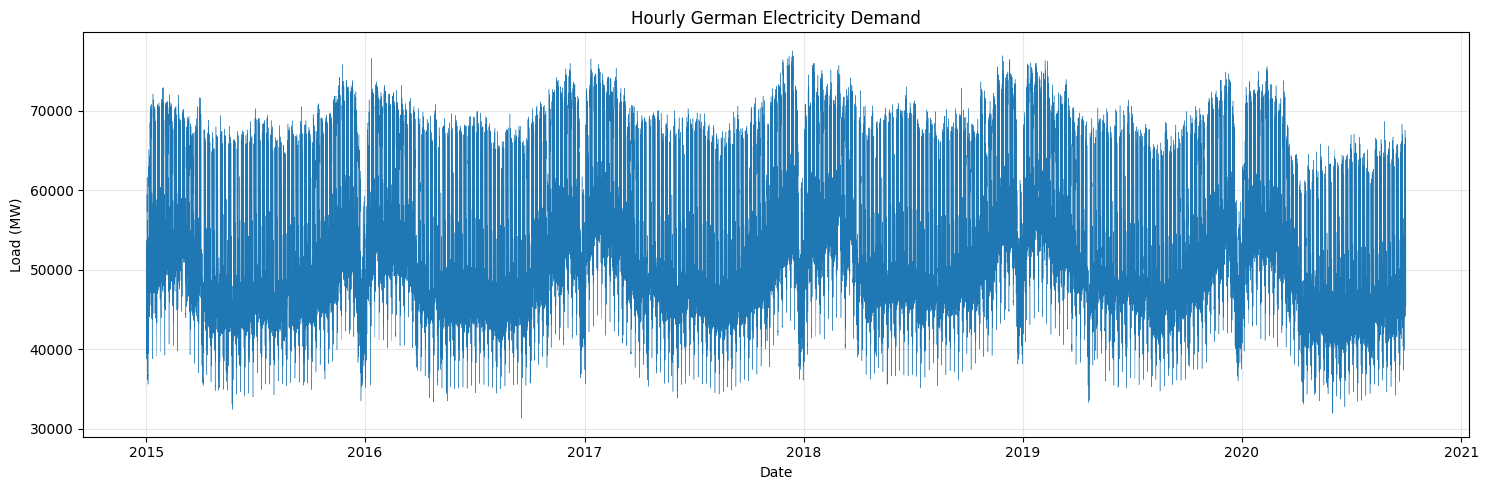

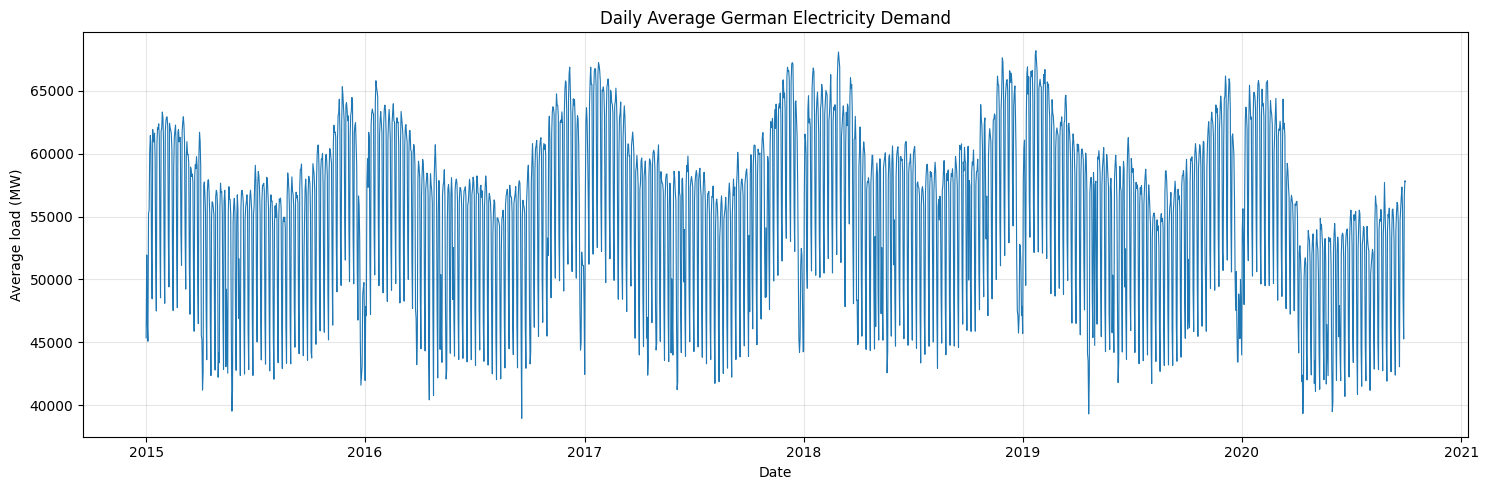

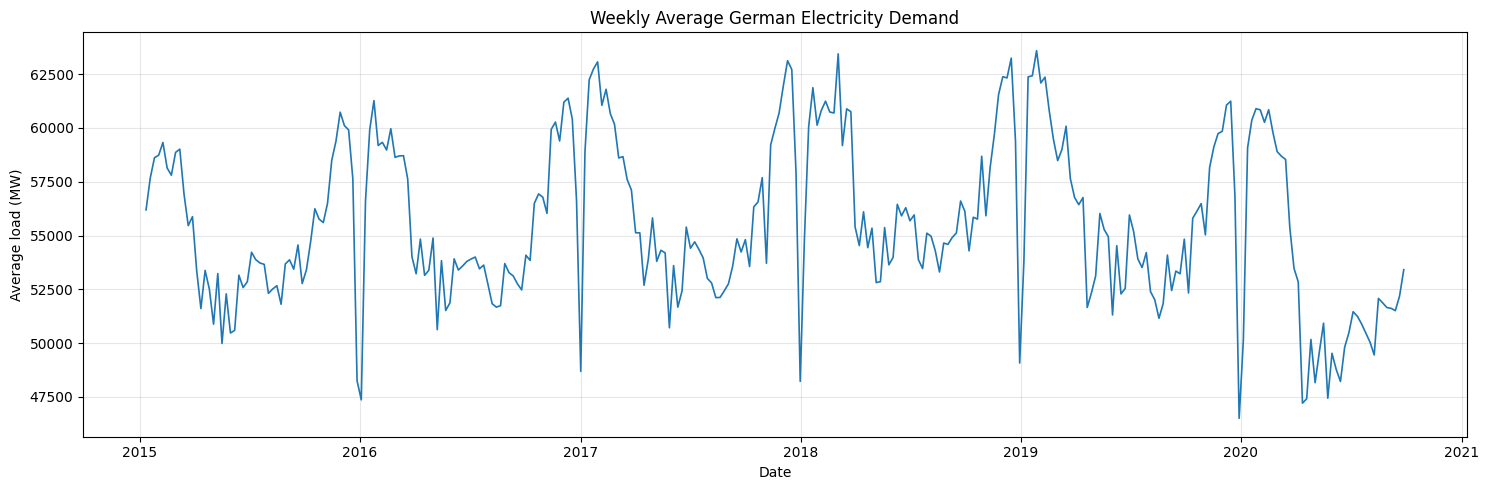

In [ ]:
# 1.4 Initial time-series plots
plt.figure(figsize=(15, 5))
plt.plot(hourly_load.index, hourly_load.values, linewidth=0.3)
plt.title("Hourly German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(daily_load.index, daily_load.values, linewidth=0.8)
plt.title("Daily Average German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(weekly_load.index, weekly_load.values, linewidth=1.2)
plt.title("Weekly Average German Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average load (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 1.5 EDA summary
eda_summary = pd.DataFrame({
    "hourly": hourly_load.describe(),
    "daily": daily_load.describe(),
    "weekly": weekly_load.describe()
})
display(eda_summary)

print("Hourly missing:", hourly_load.isna().sum())
print("Daily missing:", daily_load.isna().sum())
print("Weekly missing:", weekly_load.isna().sum())


,hourly,daily,weekly
count,"50,400.00","2,100.00",299.00
mean,"55,492.47","55,492.47","55,505.50"
std,"10,015.43","6,601.47","3,743.25"
min,"31,307.00","38,952.67","46,505.31"
25%,"47,106.00","50,413.45","52,848.76"
50%,"55,092.00","56,776.92","54,858.43"
75%,"64,309.25","60,430.09","58,693.59"
max,"77,549.00","68,183.58","63,587.01"


Hourly missing: 0
Daily missing: 0
Weekly missing: 0


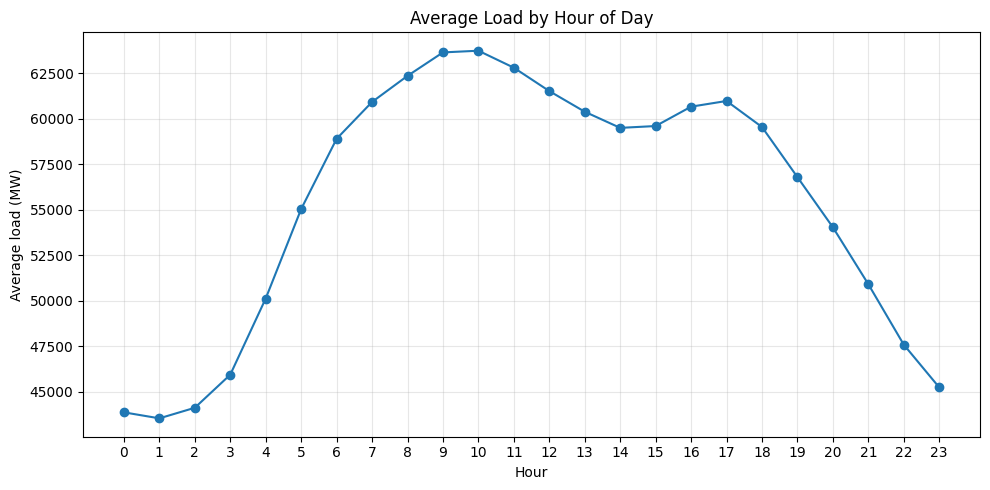

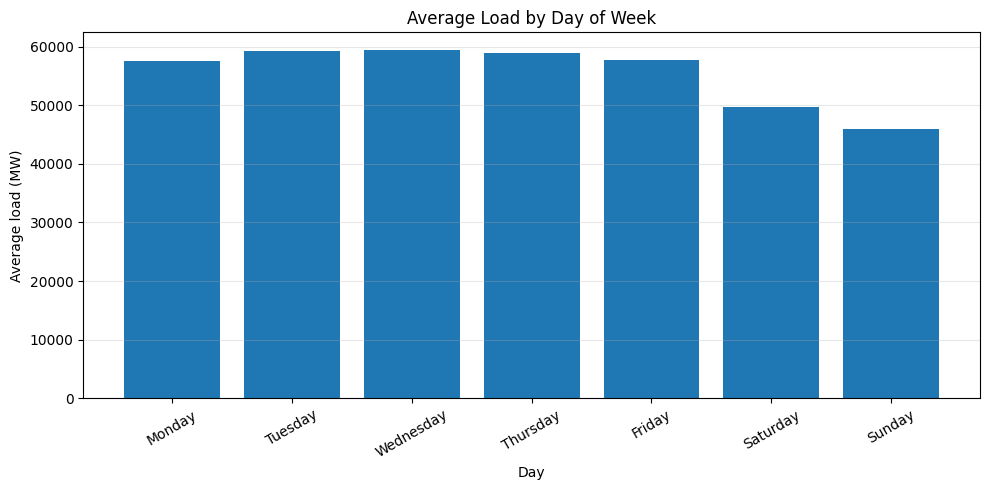

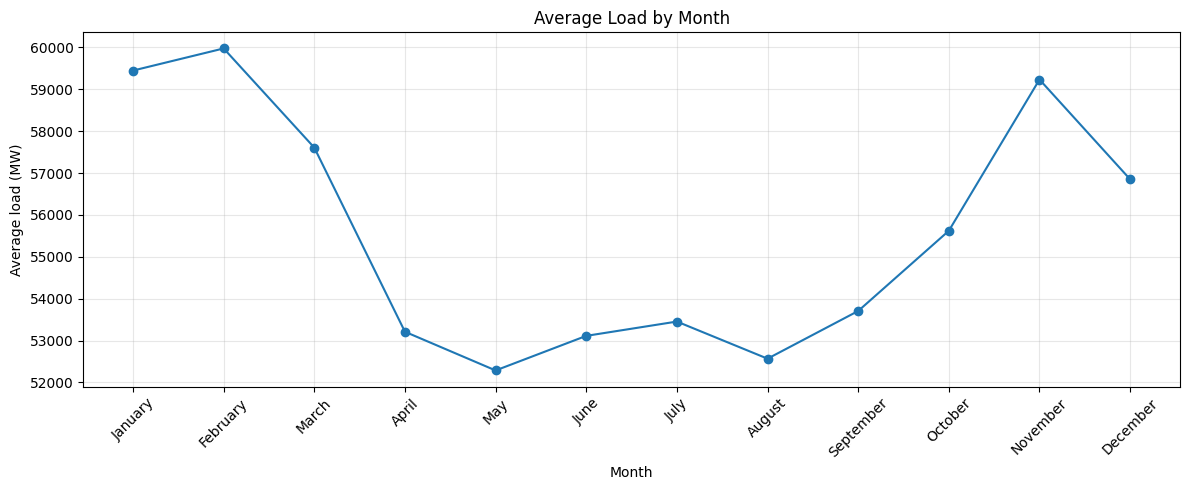

In [ ]:
# 1.6 Intraday, weekly and annual seasonal patterns
hour_pattern = hourly_load.groupby(hourly_load.index.hour).mean()

plt.figure(figsize=(10, 5))
plt.plot(hour_pattern.index, hour_pattern.values, marker="o")
plt.title("Average Load by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average load (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_pattern = hourly_load.groupby(hourly_load.index.day_name()).mean().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(day_pattern.index, day_pattern.values)
plt.title("Average Load by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average load (MW)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
month_pattern = daily_load.groupby(daily_load.index.month_name()).mean().reindex(month_order)

plt.figure(figsize=(12, 5))
plt.plot(month_pattern.index, month_pattern.values, marker="o")
plt.title("Average Load by Month")
plt.xlabel("Month")
plt.ylabel("Average load (MW)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


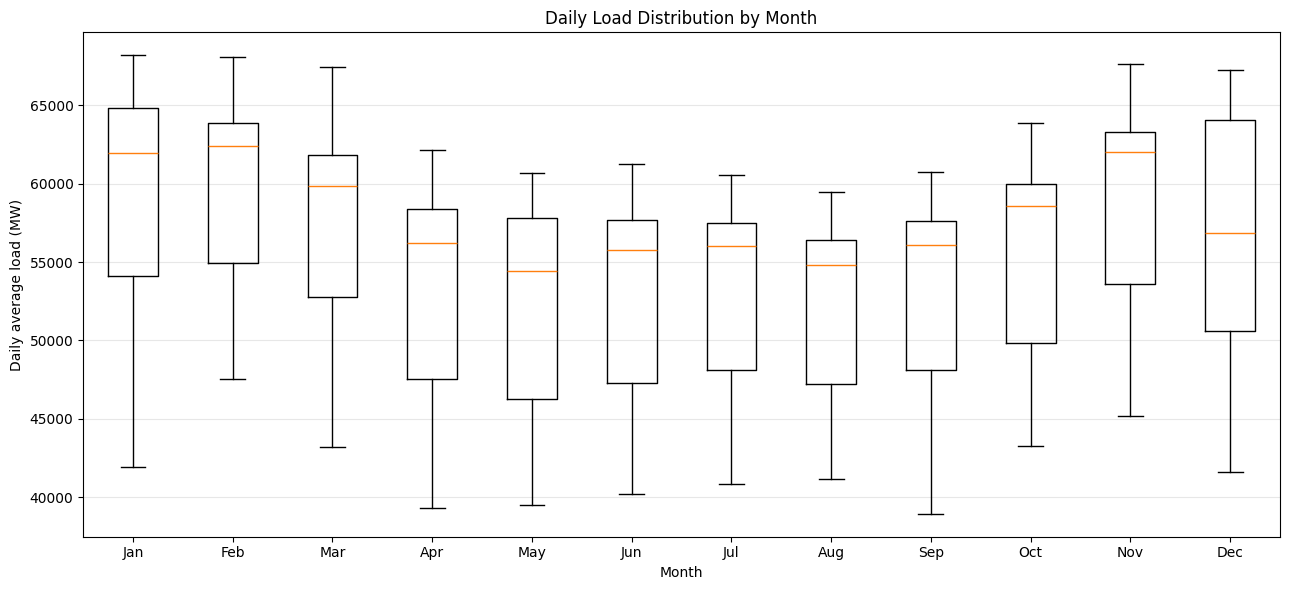

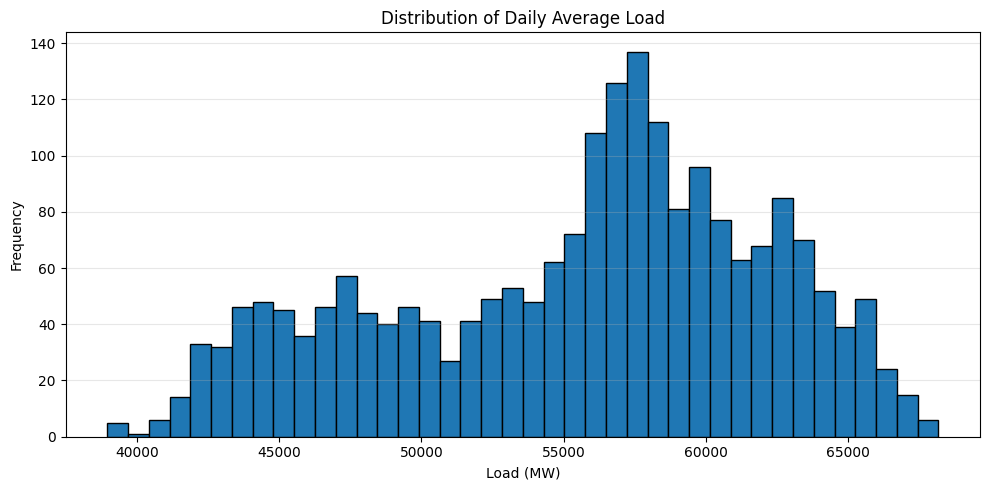

Skewness: -0.42184028365244153
Excess kurtosis: -0.7500962462896772


In [ ]:
# 1.7 Boxplots and distribution
daily_eda = daily_load.to_frame("load_mw")
daily_eda["month"] = daily_eda.index.month

month_groups = [
    daily_eda.loc[daily_eda["month"] == month, "load_mw"].dropna()
    for month in range(1, 13)
]

plt.figure(figsize=(13, 6))
plt.boxplot(
    month_groups,
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.title("Daily Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Daily average load (MW)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(daily_load.dropna(), bins=40, edgecolor="black")
plt.title("Distribution of Daily Average Load")
plt.xlabel("Load (MW)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Skewness:", daily_load.skew())
print("Excess kurtosis:", daily_load.kurtosis())


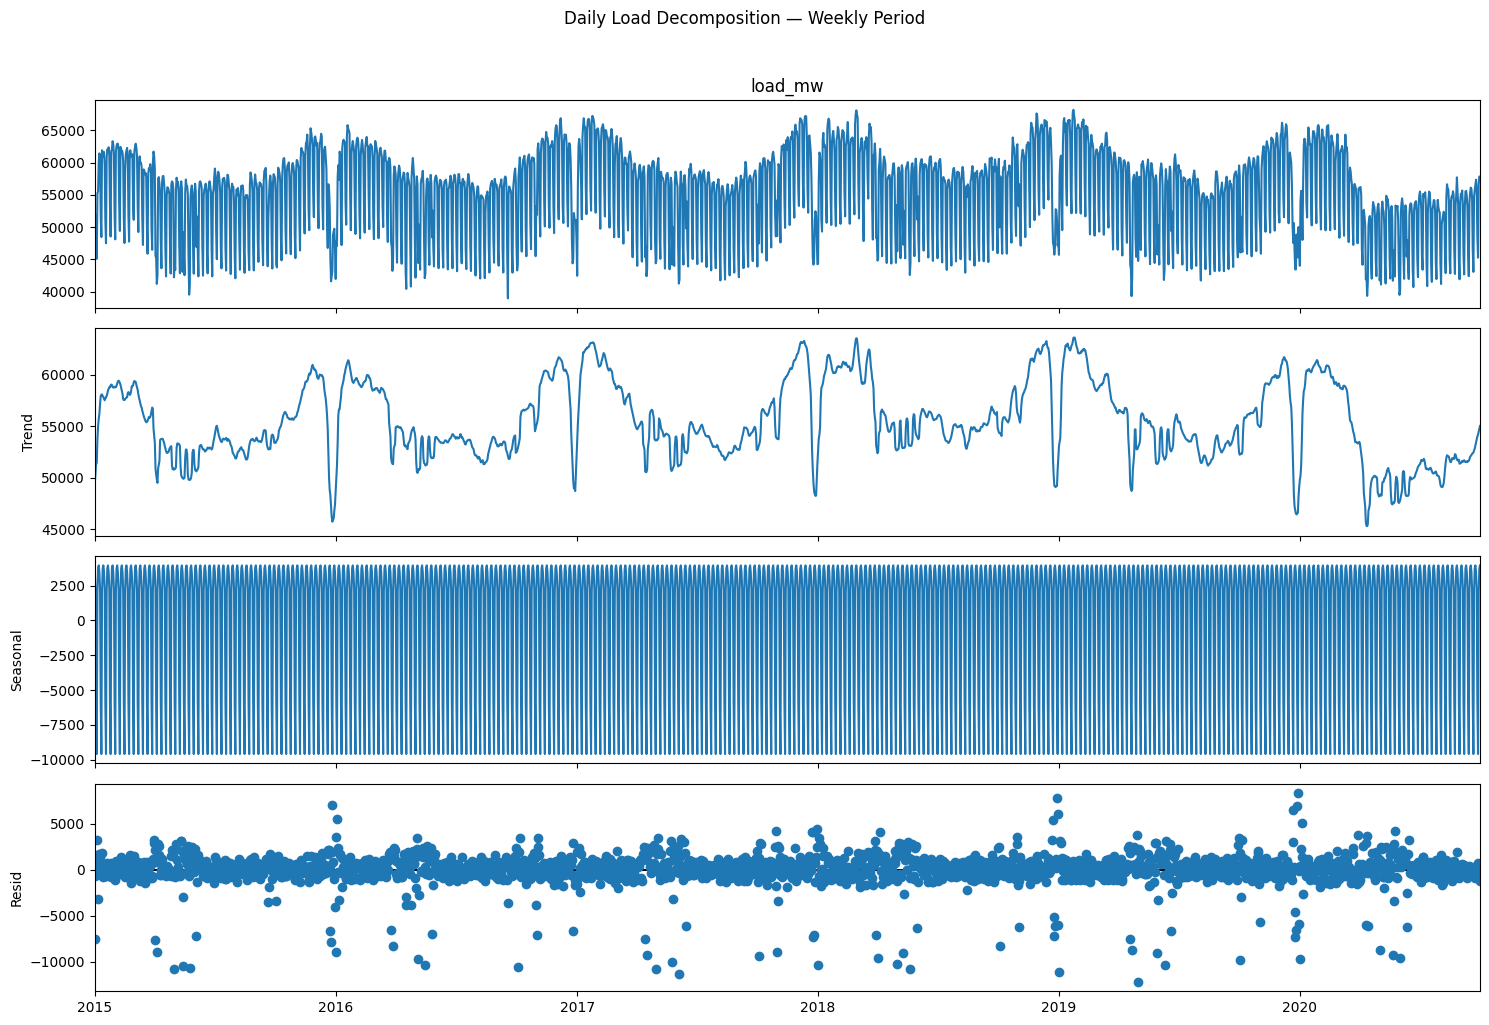

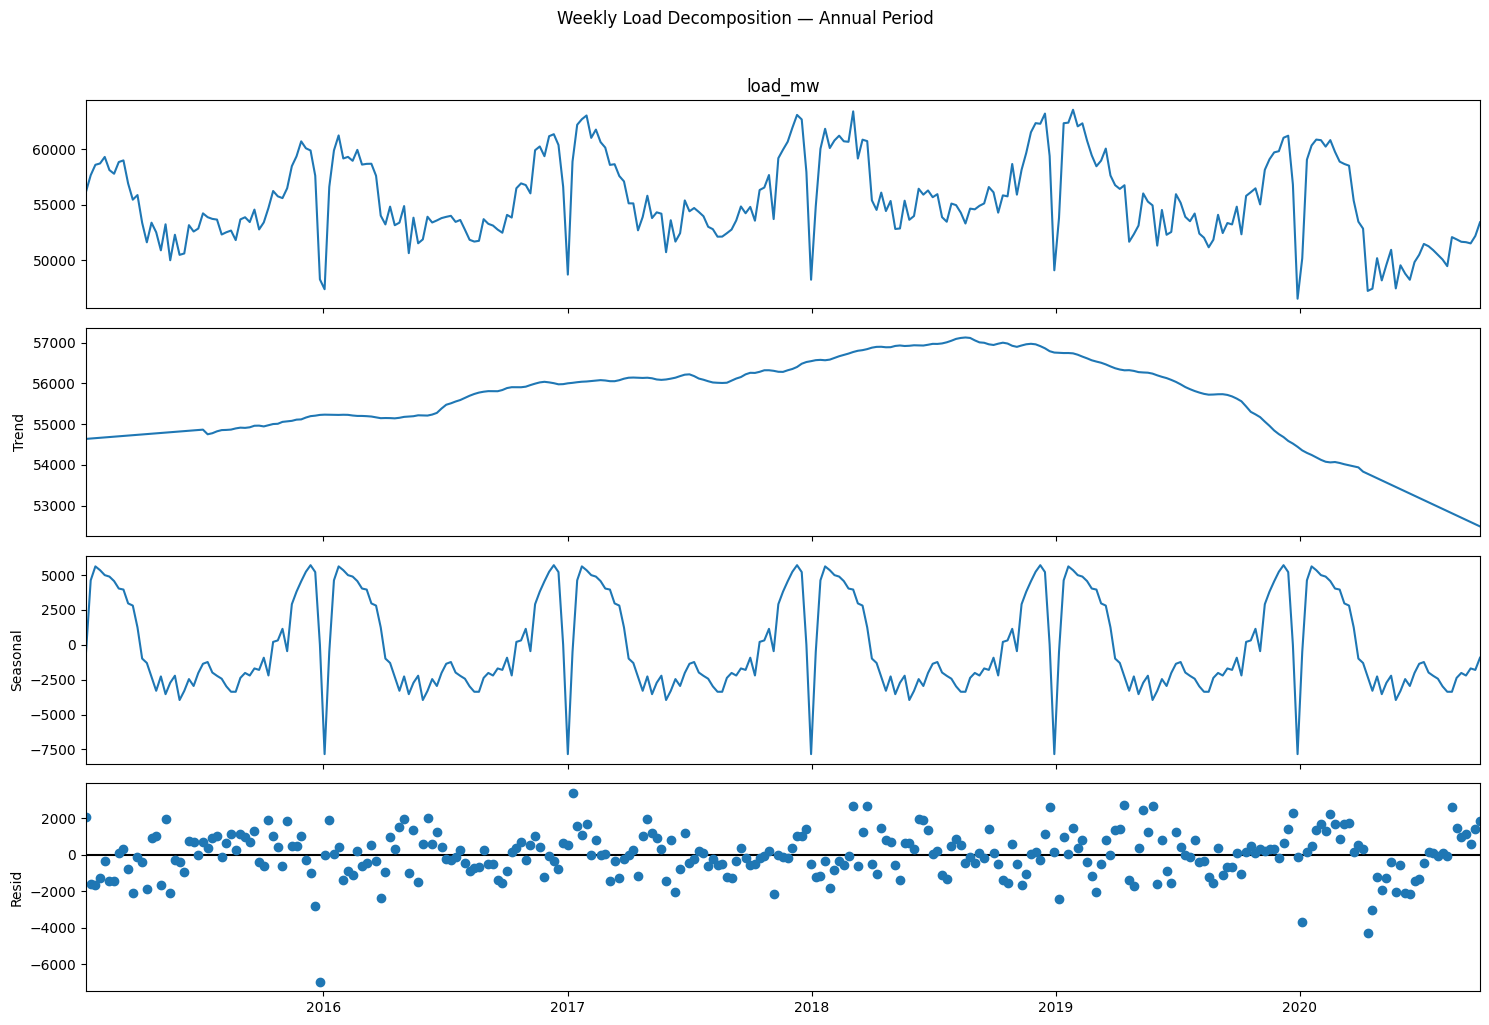

In [ ]:
# 1.8 Time-series decomposition
daily_decomposition = seasonal_decompose(
    daily_load.dropna(),
    model="additive",
    period=7,
    extrapolate_trend="freq"
)
fig = daily_decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle("Daily Load Decomposition — Weekly Period", y=1.02)
plt.tight_layout()
plt.show()

weekly_decomposition = seasonal_decompose(
    weekly_load.dropna(),
    model="additive",
    period=52,
    extrapolate_trend="freq"
)
fig = weekly_decomposition.plot()
fig.set_size_inches(15, 10)
fig.suptitle("Weekly Load Decomposition — Annual Period", y=1.02)
plt.tight_layout()
plt.show()


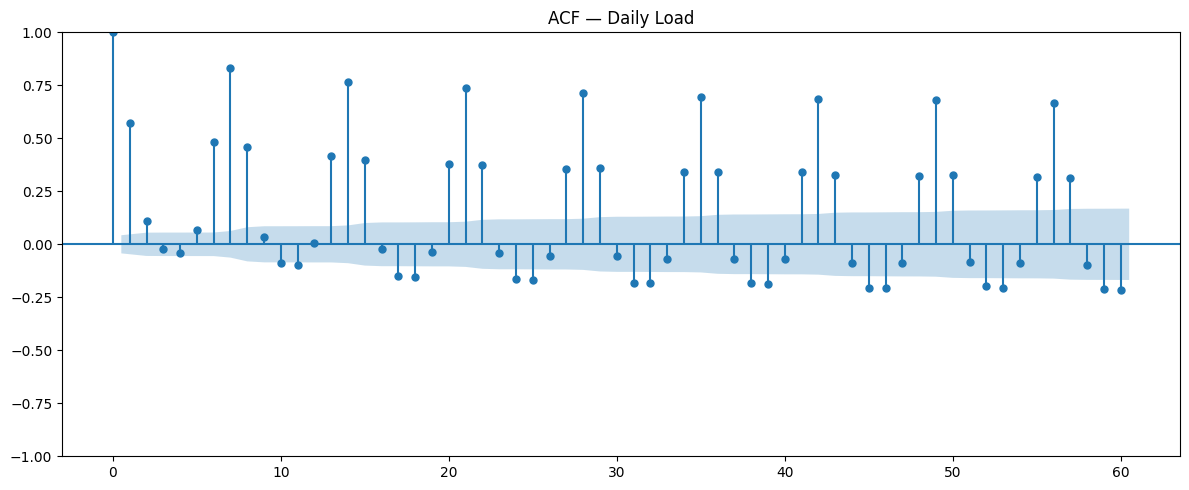

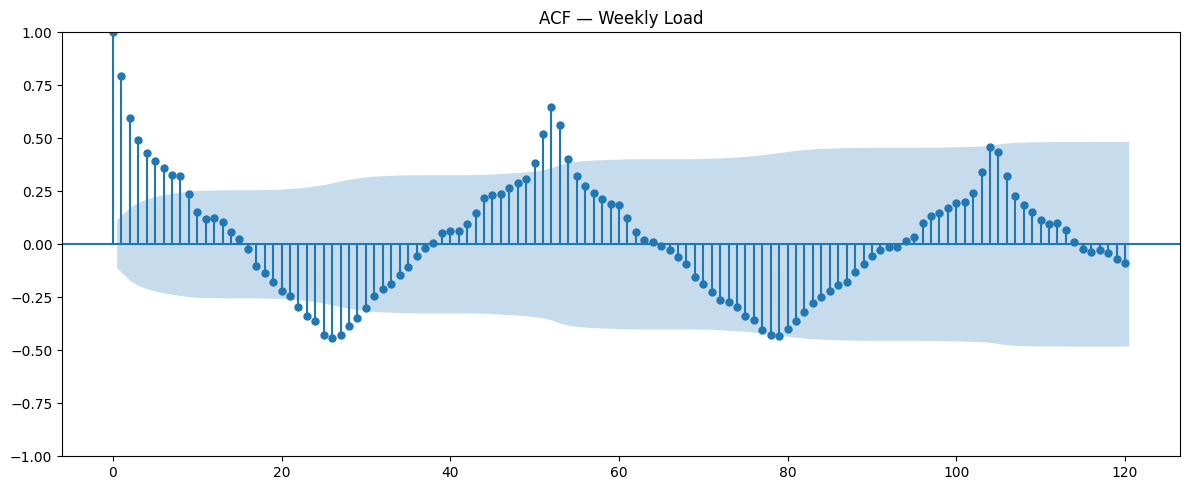

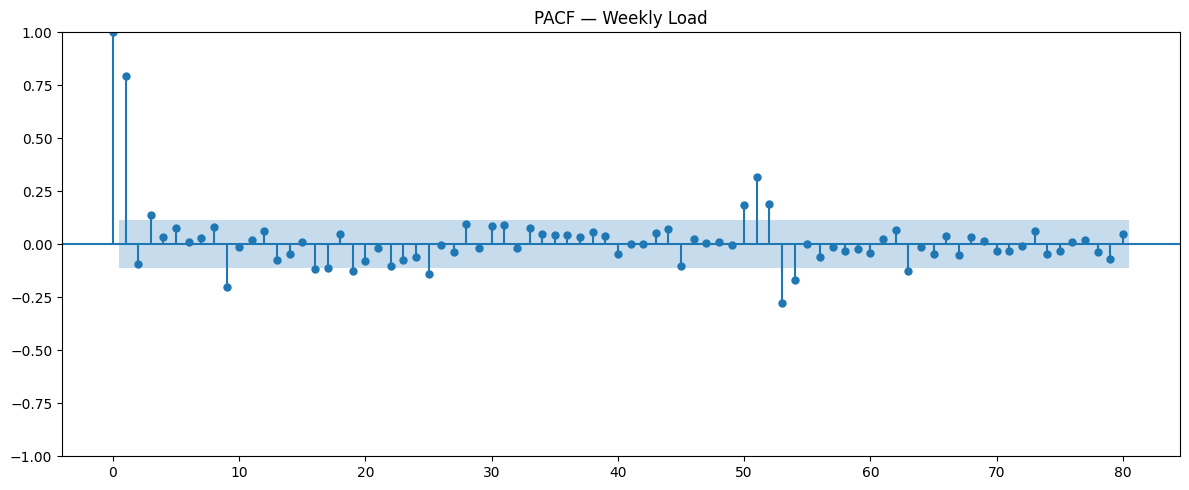

In [ ]:
# 1.9 ACF and PACF
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(daily_load.dropna(), lags=60, ax=ax)
ax.set_title("ACF — Daily Load")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(weekly_load.dropna(), lags=120, ax=ax)
ax.set_title("ACF — Weekly Load")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(weekly_load.dropna(), lags=80, method="ywm", ax=ax)
ax.set_title("PACF — Weekly Load")
plt.tight_layout()
plt.show()


In [ ]:
# 1.10 Stationarity helper functions
def adf_result(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    output = {
        "series": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "lags": result[2],
        "n": result[3],
        "stationary_at_5pct": result[1] < 0.05
    }
    return output

def kpss_result(series, name):
    statistic, p_value, lags, critical_values = kpss(
        series.dropna(),
        regression="c",
        nlags="auto"
    )
    output = {
        "series": name,
        "KPSS statistic": statistic,
        "p-value": p_value,
        "lags": lags,
        "stationary_at_5pct": p_value >= 0.05
    }
    return output

weekly_diff1 = weekly_load.diff(1).dropna()
weekly_diff52 = weekly_load.diff(52).dropna()
weekly_diff1_52 = weekly_load.diff(1).diff(52).dropna()

adf_table = pd.DataFrame([
    adf_result(weekly_load, "Original weekly"),
    adf_result(weekly_diff1, "First difference"),
    adf_result(weekly_diff52, "Seasonal difference 52"),
    adf_result(weekly_diff1_52, "First + seasonal difference")
])

kpss_table = pd.DataFrame([
    kpss_result(weekly_load, "Original weekly"),
    kpss_result(weekly_diff1, "First difference"),
    kpss_result(weekly_diff52, "Seasonal difference 52"),
    kpss_result(weekly_diff1_52, "First + seasonal difference")
])

display(adf_table)
display(kpss_table)


,series,ADF statistic,p-value,lags,n,stationary_at_5pct
0,Original weekly,-3.90,0.00,8,290,True
1,First difference,-7.04,0.00,7,290,True
2,Seasonal difference 52,-1.80,0.38,11,235,False
3,First + seasonal difference,-7.69,0.00,10,235,True


,series,KPSS statistic,p-value,lags,stationary_at_5pct
0,Original weekly,0.16,0.10,9,True
1,First difference,0.03,0.10,22,True
2,Seasonal difference 52,1.42,0.01,9,False
3,First + seasonal difference,0.03,0.10,12,True


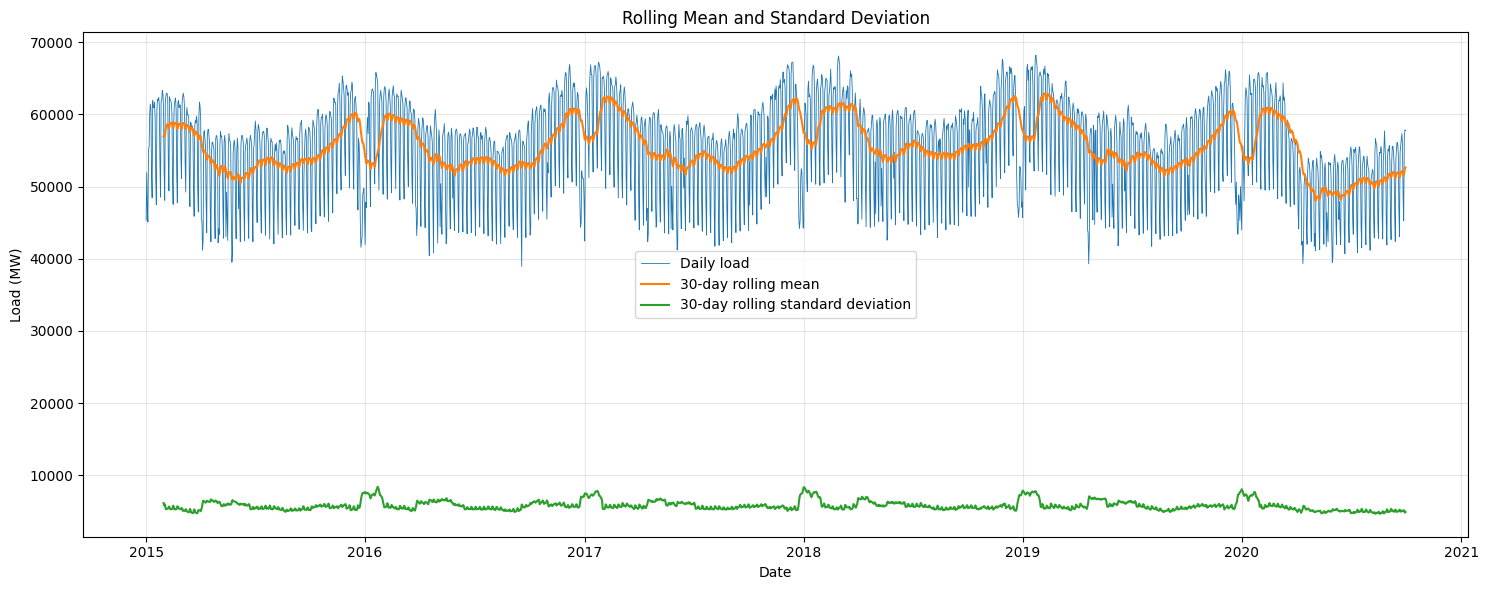

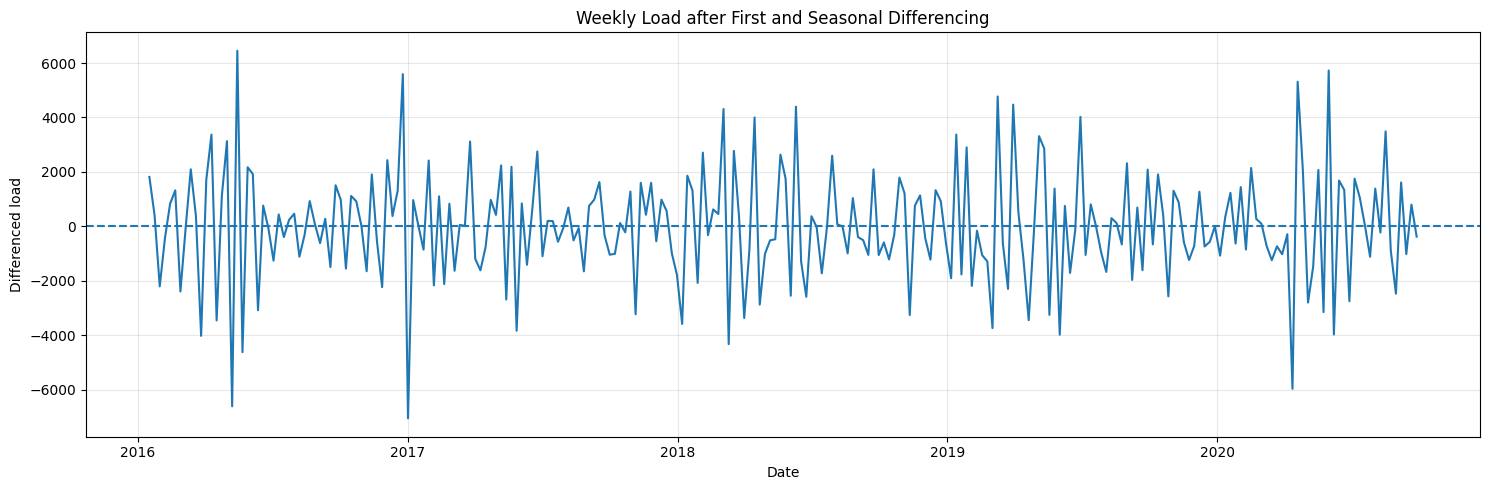

In [ ]:
# 1.11 Rolling statistics and differenced series
rolling_mean = daily_load.rolling(30).mean()
rolling_std = daily_load.rolling(30).std()

plt.figure(figsize=(15, 6))
plt.plot(daily_load.index, daily_load.values, label="Daily load", linewidth=0.6)
plt.plot(rolling_mean.index, rolling_mean.values, label="30-day rolling mean")
plt.plot(rolling_std.index, rolling_std.values, label="30-day rolling standard deviation")
plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(weekly_diff1_52.index, weekly_diff1_52.values)
plt.axhline(0, linestyle="--")
plt.title("Weekly Load after First and Seasonal Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced load")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 1.12 Save prepared datasets
hourly_load.to_frame("load_mw").to_csv("germany_hourly_load.csv")
daily_load.to_frame("load_mw").to_csv("germany_daily_load.csv")
weekly_load.to_frame("load_mw").to_csv("germany_weekly_load.csv")

print("Prepared datasets saved.")


Prepared datasets saved.


In [ ]:
FORECAST_WEEKS = 104

if len(weekly_load) <= FORECAST_WEEKS + 52:
    raise ValueError("Not enough weekly data for a 104-week test and seasonal history.")

train_weekly = weekly_load.iloc[:-FORECAST_WEEKS].copy()
test_weekly = weekly_load.iloc[-FORECAST_WEEKS:].copy()

print("Training:", train_weekly.index.min(), "to", train_weekly.index.max(), len(train_weekly))
print("Testing:", test_weekly.index.min(), "to", test_weekly.index.max(), len(test_weekly))

def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def evaluate_forecast(y_true, y_pred, model_name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(np.asarray(y_pred), index=y_true.index).astype(float)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = safe_mape(y_true.values, y_pred.values)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_percent": mape
    }

all_metrics = []
all_forecasts = {}


Training: 2015-01-11 00:00:00+00:00 to 2018-09-30 00:00:00+00:00 195
Testing: 2018-10-07 00:00:00+00:00 to 2020-09-27 00:00:00+00:00 104


# Part 2 — Benchmark models


In [ ]:
# 2.1 Mean forecast
mean_forecast = pd.Series(
    train_weekly.mean(),
    index=test_weekly.index,
    name="Mean"
)

# 2.2 Naive forecast
naive_forecast = pd.Series(
    train_weekly.iloc[-1],
    index=test_weekly.index,
    name="Naive"
)

# 2.3 Seasonal naive forecast, seasonal period = 52 weeks
seasonal_period = 52
seasonal_template = train_weekly.iloc[-seasonal_period:].values
seasonal_naive_values = np.resize(seasonal_template, len(test_weekly))
seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test_weekly.index,
    name="Seasonal Naive"
)

# 2.4 Drift forecast
n_train = len(train_weekly)
drift_slope = (train_weekly.iloc[-1] - train_weekly.iloc[0]) / (n_train - 1)
steps = np.arange(1, len(test_weekly) + 1)
drift_forecast = pd.Series(
    train_weekly.iloc[-1] + drift_slope * steps,
    index=test_weekly.index,
    name="Drift"
)

benchmark_forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

for name, forecast in benchmark_forecasts.items():
    all_metrics.append(evaluate_forecast(test_weekly, forecast, name))
    all_forecasts[name] = forecast

benchmark_metrics = pd.DataFrame(all_metrics)
display(benchmark_metrics.sort_values("RMSE"))


,Model,RMSE,MAE,MAPE_percent
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15


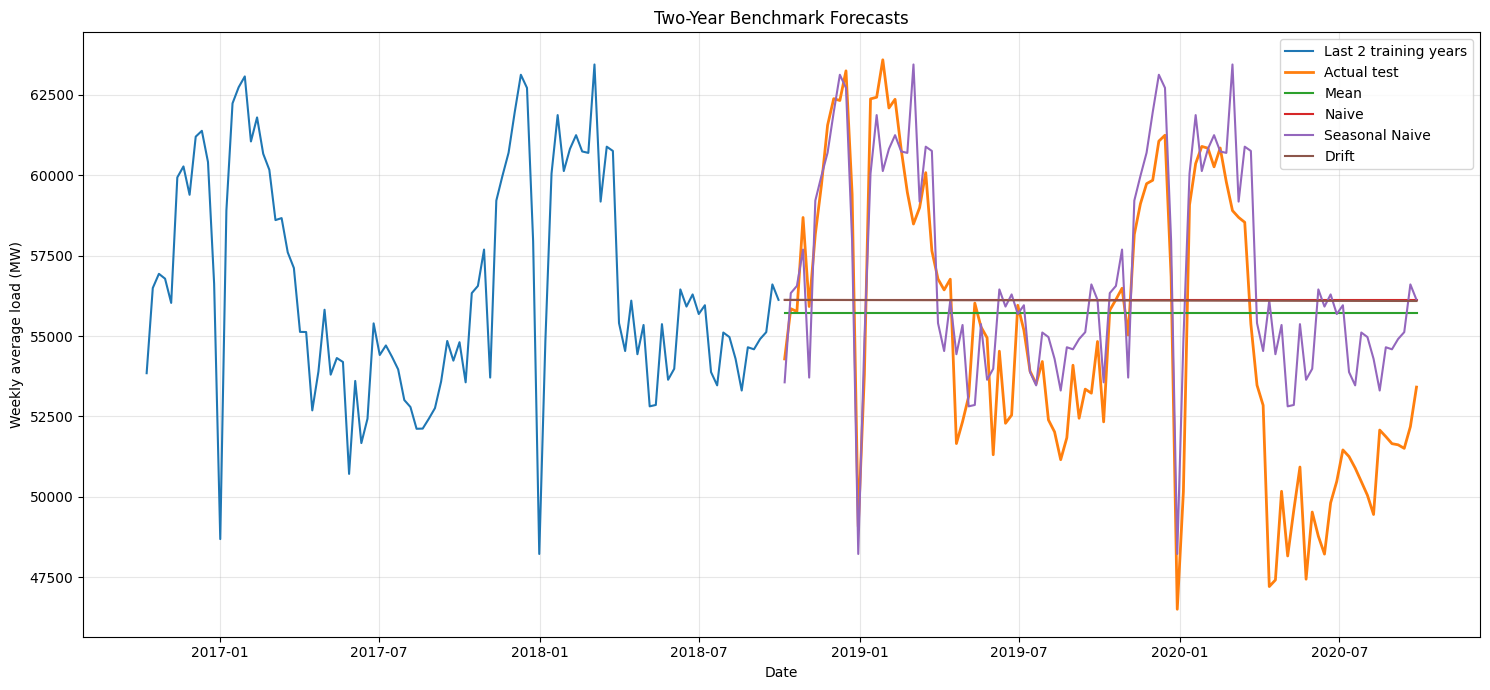

In [ ]:
# 2.5 Plot benchmark forecasts
plt.figure(figsize=(15, 7))
plt.plot(train_weekly.index[-104:], train_weekly.iloc[-104:], label="Last 2 training years")
plt.plot(test_weekly.index, test_weekly.values, label="Actual test", linewidth=2)

for name, forecast in benchmark_forecasts.items():
    plt.plot(forecast.index, forecast.values, label=name)

plt.title("Two-Year Benchmark Forecasts")
plt.xlabel("Date")
plt.ylabel("Weekly average load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Part 3 — SARIMA parameter search, residual diagnostics and forecast


In [ ]:
# 3.1 SARIMA grid settings
RUN_FULL_GRID = False

if RUN_FULL_GRID:
    p_values = range(0, 7)
    d_values = range(0, 3)
    q_values = range(0, 7)
    P_values = range(0, 7)
    D_values = range(0, 3)
    Q_values = range(0, 7)
else:
    # Use this first to verify that the notebook works.
    p_values = range(0, 3)
    d_values = range(0, 2)
    q_values = range(0, 3)
    P_values = range(0, 2)
    D_values = range(0, 2)
    Q_values = range(0, 2)

SEASONAL_PERIOD = 52

total_models = (
    len(list(p_values)) * len(list(d_values)) * len(list(q_values)) *
    len(list(P_values)) * len(list(D_values)) * len(list(Q_values))
)
print("Models to fit:", total_models)


Models to fit: 144


In [ ]:
# 3.2 AIC grid search
def sarima_aic_grid_search(
    y,
    p_values,
    d_values,
    q_values,
    P_values,
    D_values,
    Q_values,
    seasonal_period=52
):
    results = []
    best_aic = np.inf
    best_order = None
    best_seasonal_order = None

    combinations = itertools.product(
        p_values, d_values, q_values,
        P_values, D_values, Q_values
    )

    start_time = time.time()

    for i, (p, d, q, P, D, Q) in enumerate(combinations, start=1):
        order = (p, d, q)
        seasonal_order = (P, D, Q, seasonal_period)

        try:
            model = SARIMAX(
                y,
                order=order,
                seasonal_order=seasonal_order,
                trend=None,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False, maxiter=200)

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted.aic,
                "BIC": fitted.bic,
                "converged": fitted.mle_retvals.get("converged", np.nan)
            })

            if np.isfinite(fitted.aic) and fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_seasonal_order = seasonal_order

        except Exception as error:
            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": np.nan,
                "BIC": np.nan,
                "converged": False,
                "error": str(error)
            })

        if i % 100 == 0:
            elapsed = time.time() - start_time
            print(
                f"Completed {i} fits | "
                f"best AIC={best_aic:.2f} | "
                f"elapsed={elapsed/60:.1f} minutes"
            )

    results_df = pd.DataFrame(results).sort_values("AIC", na_position="last")
    return results_df, best_order, best_seasonal_order

sarima_search_results, best_order, best_seasonal_order = sarima_aic_grid_search(
    train_weekly,
    p_values,
    d_values,
    q_values,
    P_values,
    D_values,
    Q_values,
    seasonal_period=SEASONAL_PERIOD
)

print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)
display(sarima_search_results.head(20))
sarima_search_results.to_csv("sarima_aic_search_results.csv", index=False)


Completed 100 fits | best AIC=1520.12 | elapsed=12.8 minutes
Best order: (2, 0, 1)
Best seasonal order: (0, 0, 1, 52)


,order,seasonal_order,AIC,BIC,converged
105,"(2, 0, 1)","(0, 0, 1, 52)","1,132.71","1,147.46",False
109,"(2, 0, 1)","(1, 0, 1, 52)","1,177.24","1,194.94",False
91,"(1, 1, 2)","(0, 1, 1, 52)","1,520.12","1,532.45",True
43,"(0, 1, 2)","(0, 1, 1, 52)","1,521.52","1,531.38",True
47,"(0, 1, 2)","(1, 1, 1, 52)","1,521.85","1,534.18",True
95,"(1, 1, 2)","(1, 1, 1, 52)","1,522.05","1,536.84",True
139,"(2, 1, 2)","(0, 1, 1, 52)","1,530.05","1,544.85",True
143,"(2, 1, 2)","(1, 1, 1, 52)","1,536.02","1,553.28",True
83,"(1, 1, 1)","(0, 1, 1, 52)","1,544.47","1,554.38",True
67,"(1, 0, 2)","(0, 1, 1, 52)","1,544.53","1,556.91",True


In [ ]:
# 3.3 Fit the selected SARIMA model
if best_order is None or best_seasonal_order is None:
    raise RuntimeError("No SARIMA model fitted successfully.")

sarima_model = SARIMAX(
    train_weekly,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False, maxiter=500)
print(sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                            load_mw   No. Observations:                  195
Model:             SARIMAX(2, 0, 1)x(0, 0, 1, 52)   Log Likelihood                -561.356
Date:                            Tue, 14 Jul 2026   AIC                           1132.711
Time:                                    21:23:59   BIC                           1147.455
Sample:                                01-11-2015   HQIC                          1138.703
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          4.3235      0.059     72.957      0.000       4.207       4.440
ar.L2         -3.3213      0.057   

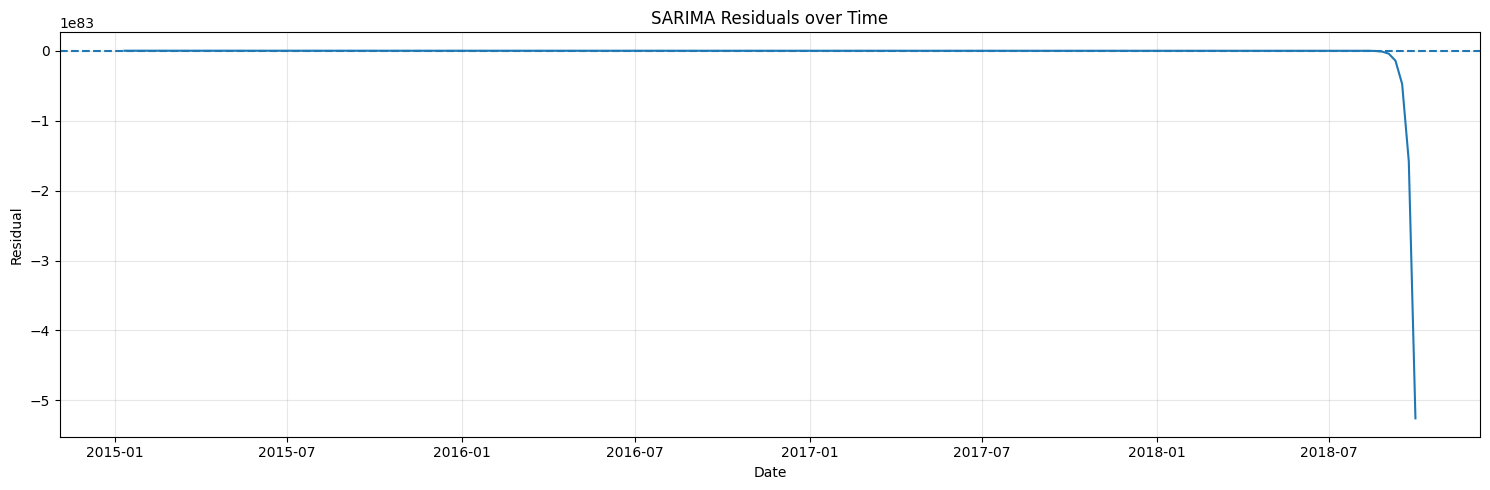

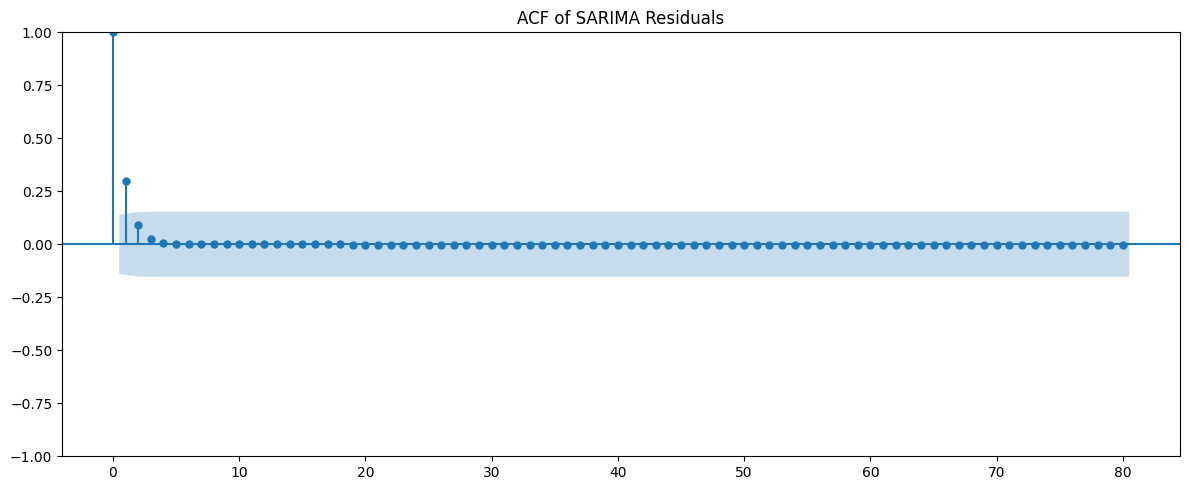

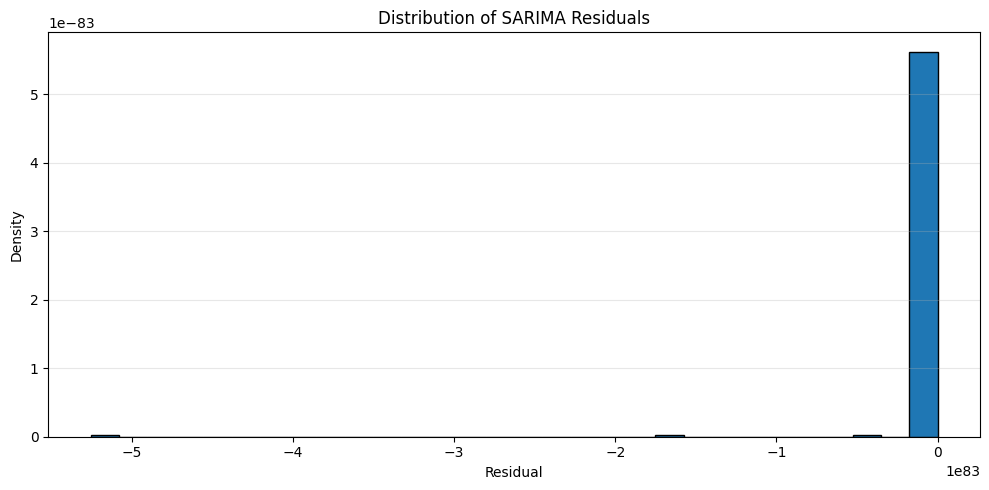

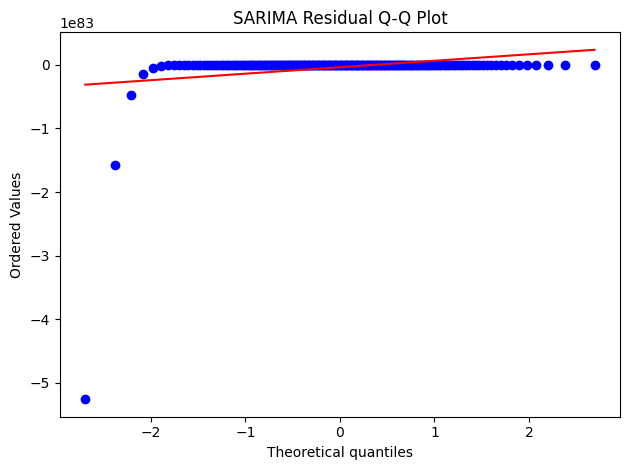

,lb_stat,lb_pvalue
10,19.70,0.03
20,19.70,0.48
52,19.73,1.00


In [ ]:
# 3.4 Residual diagnostics
sarima_residuals = sarima_fit.resid.dropna()

plt.figure(figsize=(15, 5))
plt.plot(sarima_residuals.index, sarima_residuals.values)
plt.axhline(0, linestyle="--")
plt.title("SARIMA Residuals over Time")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(sarima_residuals, lags=min(80, len(sarima_residuals)//2 - 1), ax=ax)
ax.set_title("ACF of SARIMA Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(sarima_residuals, bins=30, density=True, edgecolor="black")
plt.title("Distribution of SARIMA Residuals")
plt.xlabel("Residual")
plt.ylabel("Density")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

stats.probplot(sarima_residuals, dist="norm", plot=plt)
plt.title("SARIMA Residual Q-Q Plot")
plt.tight_layout()
plt.show()

ljung_box = acorr_ljungbox(
    sarima_residuals,
    lags=[10, 20, 52],
    return_df=True
)
display(ljung_box)


In [ ]:
# 3.5 Forecast the final two years with confidence intervals
sarima_forecast_result = sarima_fit.get_forecast(steps=len(test_weekly))
sarima_forecast = sarima_forecast_result.predicted_mean
sarima_forecast.index = test_weekly.index

sarima_ci = sarima_forecast_result.conf_int(alpha=0.05)
sarima_ci.index = test_weekly.index

all_metrics.append(evaluate_forecast(test_weekly, sarima_forecast, "SARIMA"))
all_forecasts["SARIMA"] = sarima_forecast

display(pd.DataFrame(all_metrics).sort_values("RMSE"))


,Model,RMSE,MAE,MAPE_percent
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,..."


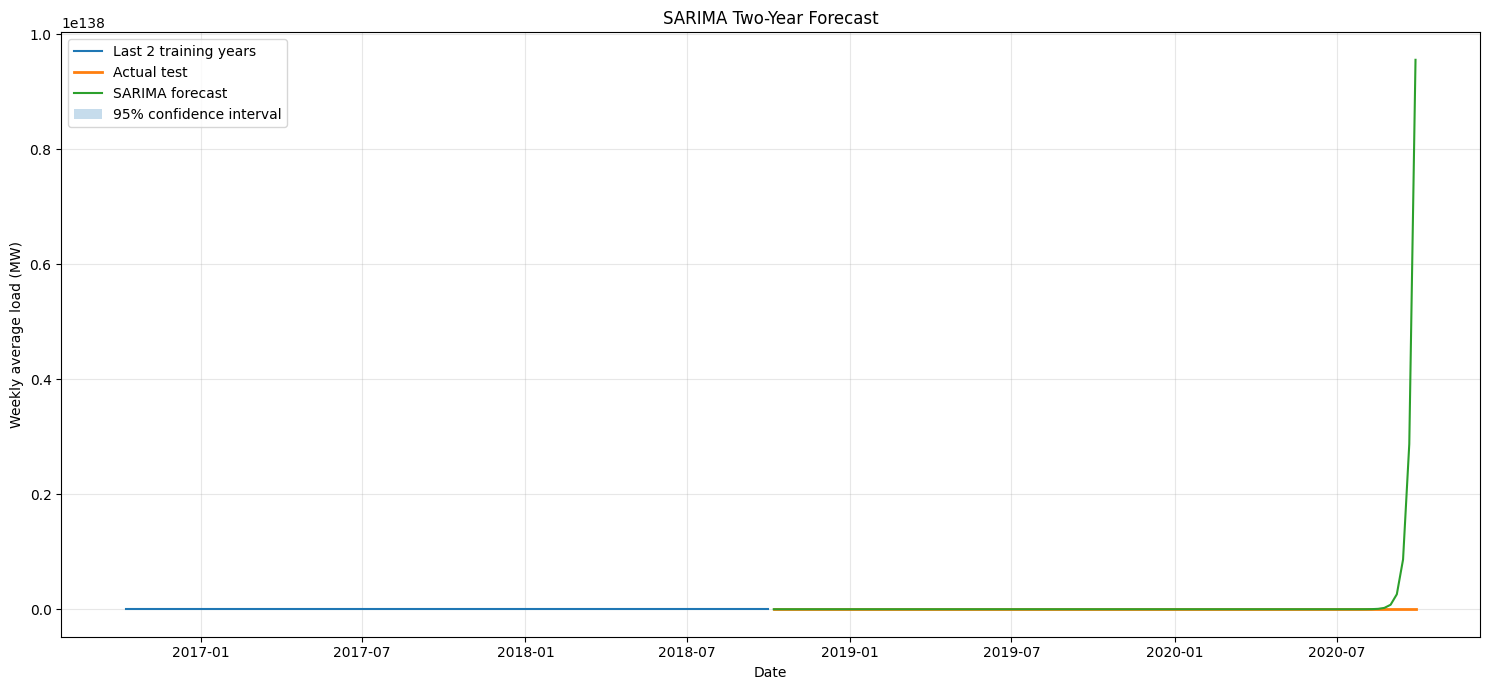

In [ ]:
# 3.6 SARIMA forecast plot
plt.figure(figsize=(15, 7))
plt.plot(train_weekly.index[-104:], train_weekly.iloc[-104:], label="Last 2 training years")
plt.plot(test_weekly.index, test_weekly.values, label="Actual test", linewidth=2)
plt.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA forecast")

plt.fill_between(
    test_weekly.index,
    sarima_ci.iloc[:, 0].values,
    sarima_ci.iloc[:, 1].values,
    alpha=0.25,
    label="95% confidence interval"
)

plt.title("SARIMA Two-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly average load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Part 4 — Temperature, holidays and SARIMAX

In [ ]:
# 4.1 Download Berlin daily historical weather
# Berlin coordinates
BERLIN_LAT = 52.52
BERLIN_LON = 13.405

weather_start = hourly_load.index.min().date().isoformat()
weather_end = hourly_load.index.max().date().isoformat()

weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": BERLIN_LAT,
    "longitude": BERLIN_LON,
    "start_date": weather_start,
    "end_date": weather_end,
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_min",
        "temperature_2m_max"
    ],
    "timezone": "Europe/Berlin"
}

response = requests.get(weather_url, params=weather_params, timeout=120)
response.raise_for_status()
weather_json = response.json()

weather_daily = pd.DataFrame({
    "date": pd.to_datetime(weather_json["daily"]["time"]),
    "temp_mean_c": weather_json["daily"]["temperature_2m_mean"],
    "temp_min_c": weather_json["daily"]["temperature_2m_min"],
    "temp_max_c": weather_json["daily"]["temperature_2m_max"]
}).set_index("date")

display(weather_daily.head())
display(weather_daily.tail())


,temp_mean_c,temp_min_c,temp_max_c
date,,,
2015-01-01,2.80,0.90,4.40
2015-01-02,4.60,1.60,7.50
2015-01-03,3.90,2.90,5.10
2015-01-04,3.00,1.60,4.20
2015-01-05,2.80,1.10,3.70


,temp_mean_c,temp_min_c,temp_max_c
date,,,
2020-09-26,10.70,9.50,11.90
2020-09-27,9.60,6.90,11.40
2020-09-28,12.50,7.60,17.40
2020-09-29,13.50,10.00,17.70
2020-09-30,12.80,7.70,18.10


In [ ]:
# 4.2 Convert daily temperature to weekly values aligned to W-SUN
weather_weekly = weather_daily.resample("W-SUN").agg({
    "temp_mean_c": "mean",
    "temp_min_c": "min",
    "temp_max_c": "max"
})

# Remove timezone from electricity index only for merging by calendar date.
weekly_load_naive_index = weekly_load.copy()
weekly_load_naive_index.index = weekly_load_naive_index.index.tz_localize(None)

weekly_data = weekly_load_naive_index.to_frame("load_mw").join(
    weather_weekly,
    how="inner"
).dropna()

print(weekly_data.shape)
display(weekly_data.head())


(299, 4)


,load_mw,temp_mean_c,temp_min_c,temp_max_c
2015-01-11,"56,191.10",3.90,-0.50,11.60
2015-01-18,"57,672.68",4.91,-2.90,11.20
2015-01-25,"58,613.30",0.04,-3.60,3.40
2015-02-01,"58,734.03",1.41,-1.20,4.70
2015-02-08,"59,323.90",-1.20,-8.20,2.90


In [ ]:
# 4.3 Add German public-holiday counts by week
import holidays

german_holidays = holidays.Germany(
    years=range(2015, 2021)
)

holiday_daily = pd.Series(
    0,
    index=pd.date_range(
        weekly_data.index.min() - pd.Timedelta(days=7),
        weekly_data.index.max(),
        freq="D"
    ),
    dtype=float
)

for holiday_date in german_holidays:
    holiday_timestamp = pd.Timestamp(holiday_date)
    if holiday_timestamp in holiday_daily.index:
        holiday_daily.loc[holiday_timestamp] = 1

holiday_weekly = holiday_daily.resample("W-SUN").sum().rename("holiday_count")

weekly_data = weekly_data.join(holiday_weekly, how="left")
weekly_data["holiday_count"] = weekly_data["holiday_count"].fillna(0)

display(weekly_data.head())


,load_mw,temp_mean_c,temp_min_c,temp_max_c,holiday_count
2015-01-11,"56,191.10",3.90,-0.50,11.60,0.00
2015-01-18,"57,672.68",4.91,-2.90,11.20,0.00
2015-01-25,"58,613.30",0.04,-3.60,3.40,0.00
2015-02-01,"58,734.03",1.41,-1.20,4.70,0.00
2015-02-08,"59,323.90",-1.20,-8.20,2.90,0.00


In [ ]:
# 4.4 Common SARIMAX split
sarimax_train = weekly_data.iloc[:-FORECAST_WEEKS].copy()
sarimax_test = weekly_data.iloc[-FORECAST_WEEKS:].copy()

exog_columns = [
    "temp_mean_c",
    "temp_min_c",
    "temp_max_c",
    "holiday_count"
]

X_train_exog = sarimax_train[exog_columns]
X_test_exog = sarimax_test[exog_columns]

y_train_sarimax = sarimax_train["load_mw"]
y_test_sarimax = sarimax_test["load_mw"]

print(y_train_sarimax.index.min(), y_train_sarimax.index.max())
print(y_test_sarimax.index.min(), y_test_sarimax.index.max())


2015-01-11 00:00:00 2018-09-30 00:00:00
2018-10-07 00:00:00 2020-09-27 00:00:00


In [ ]:
# 4.5 Fit SARIMAX using the SARIMA orders selected in Part 3
sarimax_model = SARIMAX(
    y_train_sarimax,
    exog=X_train_exog,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False, maxiter=500)
print(sarimax_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                            load_mw   No. Observations:                  195
Model:             SARIMAX(2, 0, 1)x(0, 0, 1, 52)   Log Likelihood              -18769.944
Date:                            Tue, 14 Jul 2026   AIC                          37557.887
Time:                                    21:26:04   BIC                          37584.426
Sample:                                01-11-2015   HQIC                         37568.672
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
temp_mean_c    3536.5969      4.009    882.121      0.000    3528.739    3544.455
temp_min_c    -6242.7268  

In [ ]:
# 4.6 Conditional forecast using observed future test temperatures
sarimax_result = sarimax_fit.get_forecast(
    steps=len(y_test_sarimax),
    exog=X_test_exog
)

sarimax_forecast = sarimax_result.predicted_mean
sarimax_forecast.index = y_test_sarimax.index

sarimax_ci = sarimax_result.conf_int(alpha=0.05)
sarimax_ci.index = y_test_sarimax.index

all_metrics.append(
    evaluate_forecast(y_test_sarimax, sarimax_forecast, "SARIMAX + temperature + holidays")
)
all_forecasts["SARIMAX + temperature + holidays"] = sarimax_forecast

display(pd.DataFrame(all_metrics).sort_values("RMSE"))


,Model,RMSE,MAE,MAPE_percent
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15
5,SARIMAX + temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00"
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,..."


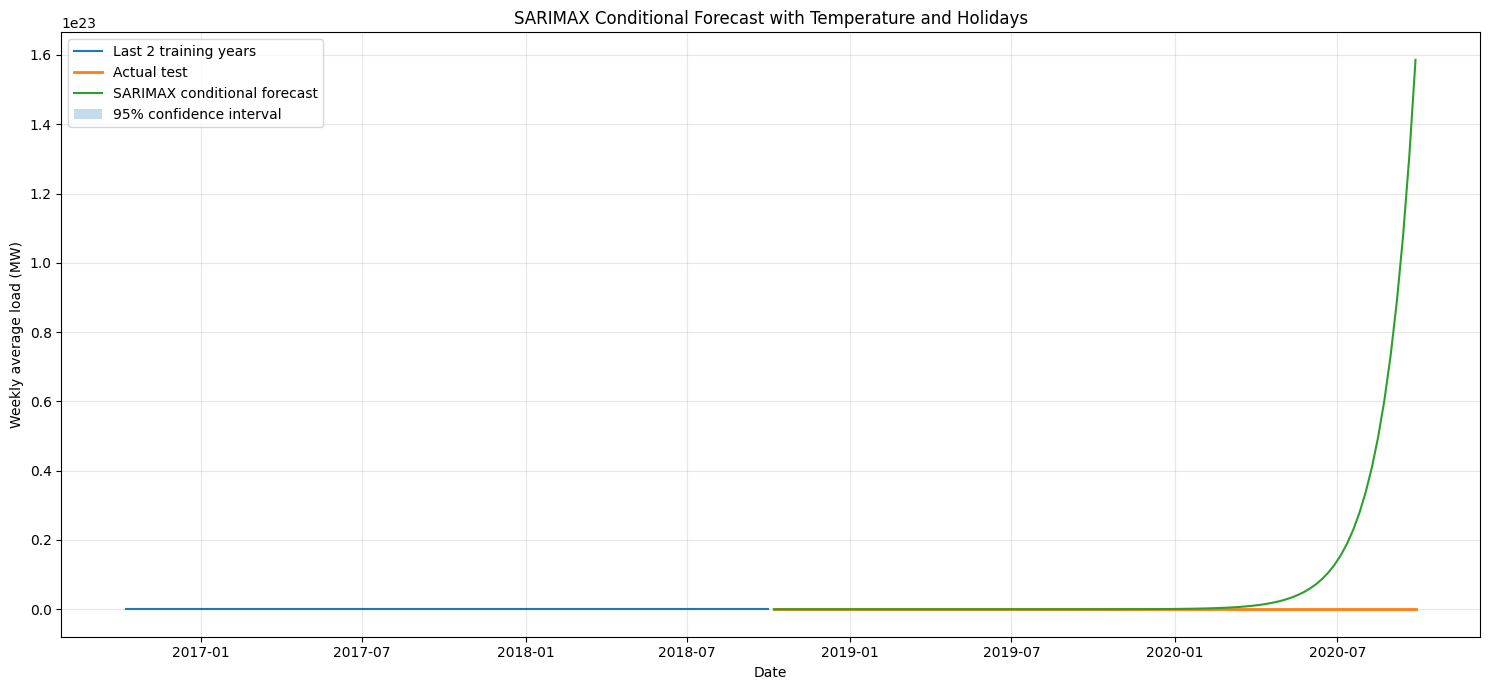

In [ ]:
# 4.7 SARIMAX forecast plot
plt.figure(figsize=(15, 7))
plt.plot(y_train_sarimax.index[-104:], y_train_sarimax.iloc[-104:], label="Last 2 training years")
plt.plot(y_test_sarimax.index, y_test_sarimax.values, label="Actual test", linewidth=2)
plt.plot(sarimax_forecast.index, sarimax_forecast.values, label="SARIMAX conditional forecast")

plt.fill_between(
    y_test_sarimax.index,
    sarimax_ci.iloc[:, 0].values,
    sarimax_ci.iloc[:, 1].values,
    alpha=0.25,
    label="95% confidence interval"
)

plt.title("SARIMAX Conditional Forecast with Temperature and Holidays")
plt.xlabel("Date")
plt.ylabel("Weekly average load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Part 5 — Feature-based regression

In [ ]:
# 5.1 Feature engineering without leakage
def create_weekly_features(data):
    features = data.copy()

    # Calendar features known in advance.
    features["weekofyear"] = features.index.isocalendar().week.astype(int)
    features["year"] = features.index.year
    features["sin_week"] = np.sin(2 * np.pi * features["weekofyear"] / 52.0)
    features["cos_week"] = np.cos(2 * np.pi * features["weekofyear"] / 52.0)

    # Load lags: past target values only.
    for lag in [1, 2, 3, 4, 13, 26, 52]:
        features[f"load_lag_{lag}"] = features["load_mw"].shift(lag)

    # Rolling features shifted by one week.
    shifted_load = features["load_mw"].shift(1)
    for window in [4, 13, 26, 52]:
        features[f"load_roll_mean_{window}"] = shifted_load.rolling(window).mean()
        features[f"load_roll_std_{window}"] = shifted_load.rolling(window).std()

    # Temperature lag features use only previous observed temperature.
    for lag in [1, 2, 4, 52]:
        features[f"temp_mean_lag_{lag}"] = features["temp_mean_c"].shift(lag)

    shifted_temp = features["temp_mean_c"].shift(1)
    features["temp_roll_mean_4"] = shifted_temp.rolling(4).mean()
    features["temp_roll_mean_13"] = shifted_temp.rolling(13).mean()

    return features.dropna()

feature_data = create_weekly_features(weekly_data)
display(feature_data.head())
print(feature_data.shape)


,load_mw,temp_mean_c,temp_min_c,temp_max_c,holiday_count,weekofyear,year,sin_week,cos_week,load_lag_1,load_lag_2,load_lag_3,load_lag_4,load_lag_13,load_lag_26,load_lag_52,load_roll_mean_4,load_roll_std_4,load_roll_mean_13,load_roll_std_13,load_roll_mean_26,load_roll_std_26,load_roll_mean_52,load_roll_std_52,temp_mean_lag_1,temp_mean_lag_2,temp_mean_lag_4,temp_mean_lag_52,temp_roll_mean_4,temp_roll_mean_13
2016-01-10,"56,615.14",-3.31,-9.10,4.00,0.00,1,2016,0.12,0.99,"47,364.04","48,253.36","57,627.86","59,907.33","54,714.55","53,877.93","56,191.10","53,288.15","6,405.49","56,206.60","4,193.58","54,729.49","3,316.43","54,744.42","3,165.63",0.77,9.87,6.17,3.90,5.92,7.27
2016-01-17,"59,913.91",0.29,-5.40,4.00,0.00,2,2016,0.24,0.97,"56,615.14","47,364.04","48,253.36","57,627.86","56,243.97","53,722.52","57,672.68","52,465.10","5,404.83","56,352.80","4,170.29","54,834.77","3,331.73","54,752.57","3,169.98",-3.31,0.77,6.86,4.91,3.55,6.24
2016-01-24,"61,267.53",-3.63,-12.80,4.00,0.00,3,2016,0.35,0.94,"59,913.91","56,615.14","47,364.04","48,253.36","55,763.96","53,660.05","58,613.30","53,036.61","6,195.72","56,635.10","4,284.95","55,072.90","3,467.55","54,795.67","3,225.21",0.29,-3.31,9.87,0.04,1.90,5.77
2016-01-31,"59,185.09",6.36,0.30,9.80,0.00,4,2016,0.46,0.89,"61,267.53","59,913.91","56,615.14","47,364.04","55,601.59","52,311.18","58,734.03","56,290.15","6,263.31","57,058.45","4,460.01","55,365.50","3,659.23","54,846.72","3,306.79",-3.63,0.29,0.77,1.41,-1.47,4.77
2016-02-07,"59,329.81",5.71,-0.80,12.30,0.00,5,2016,0.57,0.82,"59,185.09","61,267.53","59,913.91","56,615.14","56,496.38","52,515.36","59,323.90","59,245.42","1,954.29","57,334.11","4,473.19","55,629.88","3,678.00","54,855.39","3,317.76",6.36,-3.63,-3.31,-1.20,-0.08,4.62


(247, 30)


In [ ]:
# 5.2 Chronological split
feature_train = feature_data.iloc[:-FORECAST_WEEKS].copy()
feature_test = feature_data.iloc[-FORECAST_WEEKS:].copy()

target_column = "load_mw"
feature_columns = [column for column in feature_data.columns if column != target_column]

X_train = feature_train[feature_columns]
y_train = feature_train[target_column]

X_test = feature_test[feature_columns]
y_test = feature_test[target_column]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Number of features:", len(feature_columns))


Training rows: 143
Testing rows: 104
Number of features: 29


In [ ]:
# 5.3 Time-series hyperparameter tuning for Random Forest
tscv = TimeSeriesSplit(n_splits=5)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_parameter_distributions = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 0.8, 1.0]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_parameter_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 5}
Best CV RMSE: 1863.4807833771276


In [ ]:
# 5.5 Gradient Boosting alternative
gbr = GradientBoostingRegressor(random_state=42)

gbr_parameter_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.85, 1.0]
}

gbr_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=gbr_parameter_distributions,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_search.fit(X_train, y_train)

best_gbr = gbr_search.best_estimator_
gbr_forecast = pd.Series(
    best_gbr.predict(X_test),
    index=y_test.index,
    name="Gradient Boosting"
)

all_metrics.append(evaluate_forecast(y_test, gbr_forecast, "Gradient Boosting"))
all_forecasts["Gradient Boosting"] = gbr_forecast

print("Best Gradient Boosting parameters:")
print(gbr_search.best_params_)
display(pd.DataFrame(all_metrics).sort_values("RMSE"))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Gradient Boosting parameters:
{'subsample': 0.85, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}


,Model,RMSE,MAE,MAPE_percent
6,Random Forest,"2,657.40","1,983.11",3.80
7,Gradient Boosting,"2,751.28","2,100.74",4.03
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15
5,SARIMAX + temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00"
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,..."


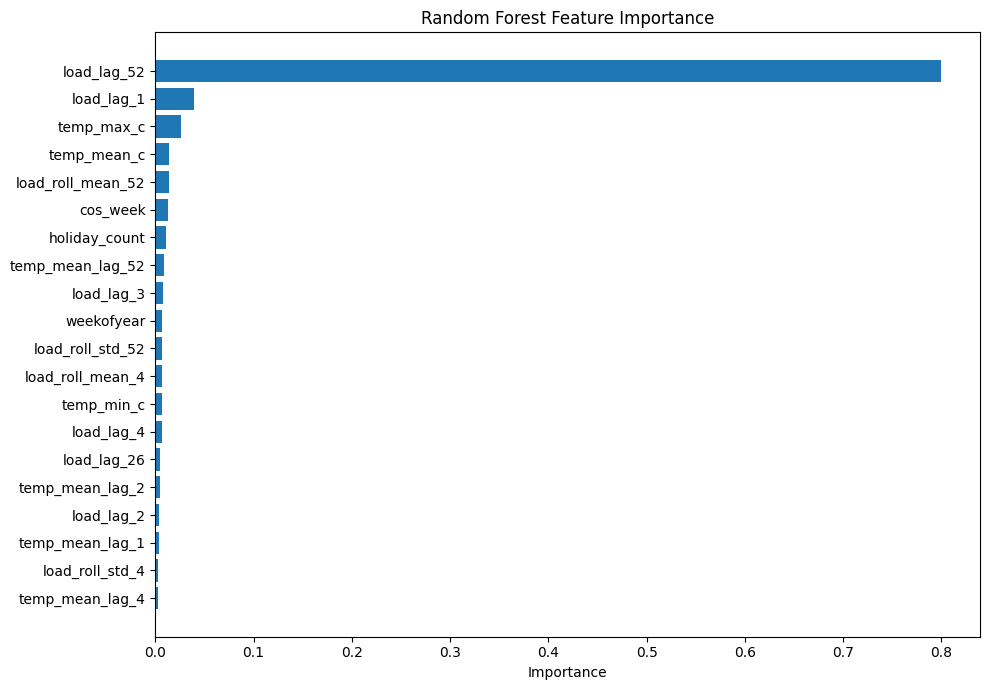

In [ ]:
# 5.6 Feature importance
importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(importance.index[::-1], importance.values[::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


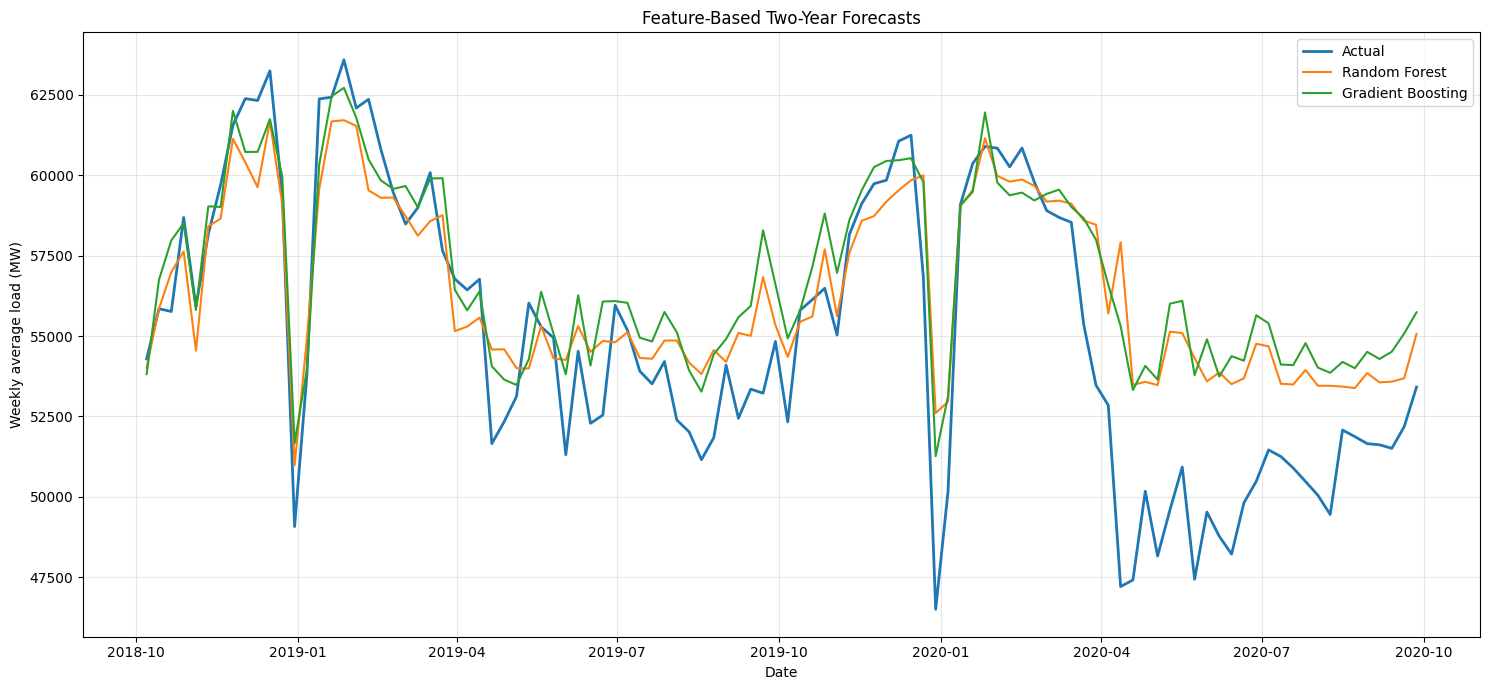

In [ ]:
# 5.7 Feature-based forecast plot
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test.values, label="Actual", linewidth=2)
plt.plot(rf_forecast.index, rf_forecast.values, label="Random Forest")
plt.plot(gbr_forecast.index, gbr_forecast.values, label="Gradient Boosting")
plt.title("Feature-Based Two-Year Forecasts")
plt.xlabel("Date")
plt.ylabel("Weekly average load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Part 6 — Hourly LSTM

The default evaluation below is a **rolling one-step-ahead** prediction across the final two years. Each prediction window contains only observations up to the previous hour. This is substantially more stable than a 17,000-step recursive forecast.

For a strict forecast made once at the beginning of the two-year test period, use the optional recursive cell.


In [ ]:
# 6.1 TensorFlow imports and hourly split
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)

HOURS_PER_TWO_YEARS = 24 * 365 * 2
hourly_train = hourly_load.iloc[:-HOURS_PER_TWO_YEARS].copy()
hourly_test = hourly_load.iloc[-HOURS_PER_TWO_YEARS:].copy()

print("Hourly train:", len(hourly_train))
print("Hourly test:", len(hourly_test))


Hourly train: 32880
Hourly test: 17520


In [ ]:
# 6.2 Scale using training data only
lstm_scaler = MinMaxScaler()

train_scaled = lstm_scaler.fit_transform(
    hourly_train.values.reshape(-1, 1)
).astype(np.float32)

# Transform the full sequence using the scaler fitted only on training data.
full_scaled = lstm_scaler.transform(
    hourly_load.values.reshape(-1, 1)
).astype(np.float32)

LOOKBACK = 24 * 7  # Previous 7 days


In [ ]:
# 6.3 Efficient TensorFlow window datasets
BATCH_SIZE = 256

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=train_scaled[:-1],
    targets=train_scaled[LOOKBACK:],
    sequence_length=LOOKBACK,
    sequence_stride=1,
    shuffle=True,
    batch_size=BATCH_SIZE
)

# Validation uses the final 10% of training time.
validation_size = int(len(train_scaled) * 0.10)
validation_start = len(train_scaled) - validation_size - LOOKBACK

validation_input = train_scaled[validation_start:]

validation_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=validation_input[:-1],
    targets=validation_input[LOOKBACK:],
    sequence_length=LOOKBACK,
    sequence_stride=1,
    shuffle=False,
    batch_size=BATCH_SIZE
)


In [ ]:
# 6.4 LSTM architecture
lstm_model = Sequential([
    tf.keras.Input(shape=(LOOKBACK, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 6.5 Train with early stopping
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5
    )
]

history = lstm_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 87s 651ms/step - loss: 0.0517 - mae: 0.1842 - val_loss: 0.0218 - val_mae: 0.1254 - learning_rate: 0.0010
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 85s 654ms/step - loss: 0.0147 - mae: 0.0954 - val_loss: 0.0052 - val_mae: 0.0518 - learning_rate: 0.0010
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 83s 650ms/step - loss: 0.0086 - mae: 0.0714 - val_loss: 0.0042 - val_mae: 0.0486 - learning_rate: 0.0010
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 83s 648ms/step - loss: 0.0066 - mae: 0.0626 - val_loss: 0.0035 - val_mae: 0.0489 - learning_rate: 0.0010
Epoch 5/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 84s 651ms/step - loss: 0.0053 - mae: 0.0567 - val_loss: 0.0024 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 6/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 85s 663ms/step - loss: 0.0043 - mae: 0.0510 - val_loss: 0.0023 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 7/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 84s 651ms/step - loss: 0.0039 - mae: 0.0485 - val_loss: 0.0025 - val_mae: 0.0415 - learnin

In [ ]:
# 6.7 Rolling one-step-ahead predictions over final two years
test_start_position = len(hourly_load) - len(hourly_test)

test_input_scaled = full_scaled[test_start_position - LOOKBACK:]

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    data=test_input_scaled[:-1],
    targets=None,
    sequence_length=LOOKBACK,
    sequence_stride=1,
    shuffle=False,
    batch_size=BATCH_SIZE
)

lstm_scaled_predictions = lstm_model.predict(test_dataset, verbose=1)
lstm_predictions = lstm_scaler.inverse_transform(lstm_scaled_predictions).ravel()

# Keep exactly the test length.
lstm_predictions = lstm_predictions[:len(hourly_test)]

lstm_forecast = pd.Series(
    lstm_predictions,
    index=hourly_test.index,
    name="LSTM"
)

lstm_hourly_metrics = evaluate_forecast(
    hourly_test,
    lstm_forecast,
    "LSTM hourly rolling one-step"
)

display(pd.DataFrame([lstm_hourly_metrics]))


69/69 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step


,Model,RMSE,MAE,MAPE_percent
0,LSTM hourly rolling one-step,"2,292.64","1,734.07",3.11


In [ ]:
# 6.8 Optional strict recursive forecast
# This forecasts every future hour using previous model predictions.
# It can accumulate error over a two-year horizon and is slower.

RUN_RECURSIVE_LSTM = False

if RUN_RECURSIVE_LSTM:
    recursive_window = train_scaled[-LOOKBACK:].reshape(-1).tolist()
    recursive_scaled_predictions = []

    for step in range(len(hourly_test)):
        model_input = np.array(
            recursive_window[-LOOKBACK:],
            dtype=np.float32
        ).reshape(1, LOOKBACK, 1)

        next_scaled = float(
            lstm_model.predict(model_input, verbose=0)[0, 0]
        )

        recursive_scaled_predictions.append(next_scaled)
        recursive_window.append(next_scaled)

        if (step + 1) % 1000 == 0:
            print("Recursive hours completed:", step + 1)

    recursive_predictions = lstm_scaler.inverse_transform(
        np.array(recursive_scaled_predictions).reshape(-1, 1)
    ).ravel()

    recursive_lstm_forecast = pd.Series(
        recursive_predictions,
        index=hourly_test.index,
        name="Recursive LSTM"
    )

    display(pd.DataFrame([
        evaluate_forecast(
            hourly_test,
            recursive_lstm_forecast,
            "LSTM strict recursive"
        )
    ]))


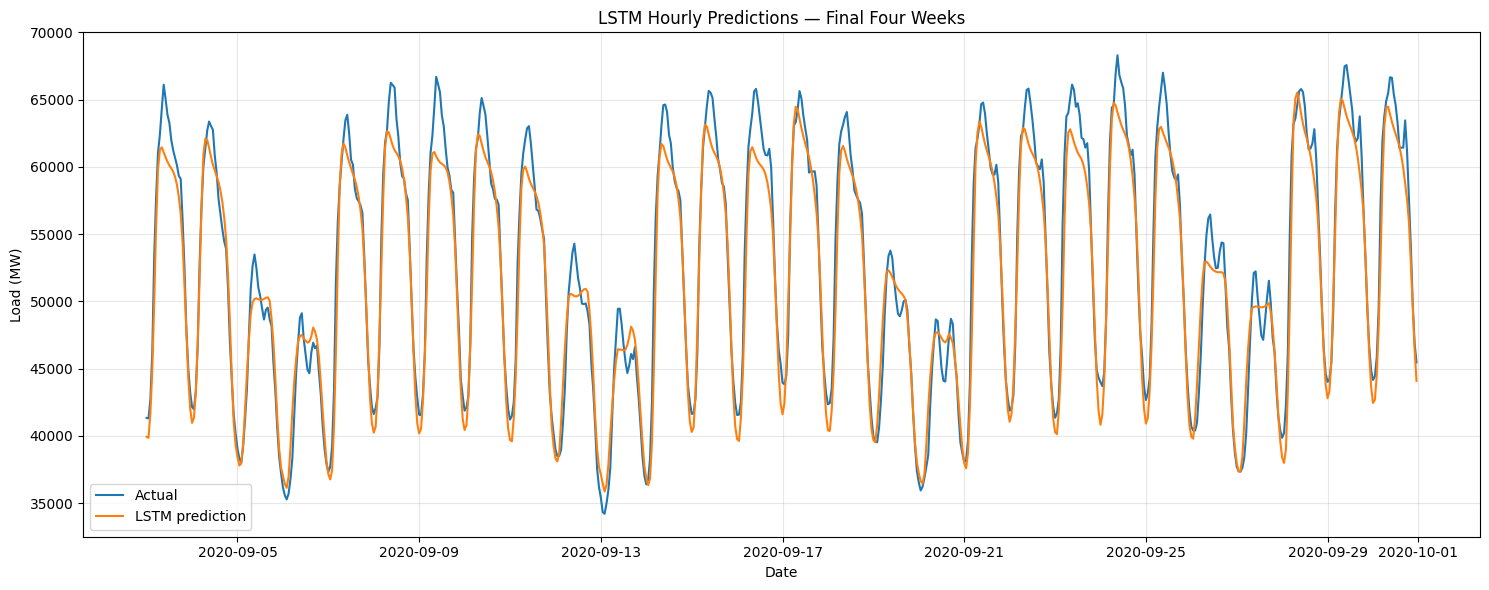

In [ ]:
# 6.9 Hourly LSTM plot — final four weeks for readability
plot_hours = 24 * 28

plt.figure(figsize=(15, 6))
plt.plot(
    hourly_test.index[-plot_hours:],
    hourly_test.iloc[-plot_hours:].values,
    label="Actual"
)
plt.plot(
    lstm_forecast.index[-plot_hours:],
    lstm_forecast.iloc[-plot_hours:].values,
    label="LSTM prediction"
)
plt.title("LSTM Hourly Predictions — Final Four Weeks")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 6.10 Aggregate hourly LSTM predictions to weekly values
lstm_weekly_actual = hourly_test.resample("W-SUN").mean()
lstm_weekly_forecast = lstm_forecast.resample("W-SUN").mean()

common_lstm_weeks = lstm_weekly_actual.index.intersection(
    lstm_weekly_forecast.index
)

lstm_weekly_actual = lstm_weekly_actual.loc[common_lstm_weeks]
lstm_weekly_forecast = lstm_weekly_forecast.loc[common_lstm_weeks]

lstm_weekly_metrics = evaluate_forecast(
    lstm_weekly_actual,
    lstm_weekly_forecast,
    "LSTM aggregated weekly"
)

all_metrics.append(lstm_weekly_metrics)
all_forecasts["LSTM aggregated weekly"] = lstm_weekly_forecast

display(pd.DataFrame(all_metrics).sort_values("RMSE"))


,Model,RMSE,MAE,MAPE_percent
8,LSTM aggregated weekly,"1,066.95",957.00,1.68
6,Random Forest,"2,657.40","1,983.11",3.80
7,Gradient Boosting,"2,751.28","2,100.74",4.03
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15
5,SARIMAX + temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00"
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,..."


# Part 7 — Comparison tables and evidence for report answers

In [ ]:
# 7.1 Final metrics table
metrics_table = pd.DataFrame(all_metrics).drop_duplicates(
    subset=["Model"],
    keep="last"
).sort_values("RMSE")

display(metrics_table)
metrics_table.to_csv("all_model_metrics.csv", index=False)


,Model,RMSE,MAE,MAPE_percent
8,LSTM aggregated weekly,"1,066.95",957.00,1.68
6,Random Forest,"2,657.40","1,983.11",3.80
7,Gradient Boosting,"2,751.28","2,100.74",4.03
2,Seasonal Naive,"2,988.25","2,288.49",4.36
0,Mean,"4,402.06","3,789.85",6.98
3,Drift,"4,466.49","3,850.78",7.14
1,Naive,"4,475.77","3,858.15",7.15
5,SARIMAX + temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00"
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,..."


In [ ]:
# 7.2 Improvement over seasonal naive
seasonal_naive_rmse = metrics_table.loc[
    metrics_table["Model"] == "Seasonal Naive",
    "RMSE"
].iloc[0]

metrics_table["RMSE_improvement_vs_seasonal_naive_percent"] = (
    (seasonal_naive_rmse - metrics_table["RMSE"]) /
    seasonal_naive_rmse * 100
)

display(
    metrics_table.sort_values(
        "RMSE_improvement_vs_seasonal_naive_percent",
        ascending=False
    )
)


,Model,RMSE,MAE,MAPE_percent,RMSE_improvement_vs_seasonal_naive_percent
8,LSTM aggregated weekly,"1,066.95",957.00,1.68,64.30
6,Random Forest,"2,657.40","1,983.11",3.80,11.07
7,Gradient Boosting,"2,751.28","2,100.74",4.03,7.93
2,Seasonal Naive,"2,988.25","2,288.49",4.36,0.00
0,Mean,"4,402.06","3,789.85",6.98,-47.31
3,Drift,"4,466.49","3,850.78",7.14,-49.47
1,Naive,"4,475.77","3,858.15",7.15,-49.78
5,SARIMAX + temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00","-918,960,554,680,167,825,408.00"
4,SARIMA,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,...","-3,287,926,203,119,611,532,611,723,097,677,834,..."


In [ ]:
# 7.3 Direct test of temperature and holiday contribution
# Compare SARIMAX variants using the same target, dates and SARIMA order.

sarimax_variants = {
    "SARIMAX no exogenous variables": [],
    "SARIMAX temperature only": ["temp_mean_c", "temp_min_c", "temp_max_c"],
    "SARIMAX holidays only": ["holiday_count"],
    "SARIMAX temperature + holidays": [
        "temp_mean_c", "temp_min_c", "temp_max_c", "holiday_count"
    ]
}

covariate_results = []

for model_name, columns in sarimax_variants.items():
    if columns:
        variant_model = SARIMAX(
            y_train_sarimax,
            exog=sarimax_train[columns],
            order=best_order,
            seasonal_order=best_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        variant_fit = variant_model.fit(disp=False, maxiter=500)
        variant_forecast = variant_fit.get_forecast(
            steps=len(y_test_sarimax),
            exog=sarimax_test[columns]
        ).predicted_mean
    else:
        variant_model = SARIMAX(
            y_train_sarimax,
            order=best_order,
            seasonal_order=best_seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        variant_fit = variant_model.fit(disp=False, maxiter=500)
        variant_forecast = variant_fit.get_forecast(
            steps=len(y_test_sarimax)
        ).predicted_mean

    variant_forecast.index = y_test_sarimax.index

    row = evaluate_forecast(
        y_test_sarimax,
        variant_forecast,
        model_name
    )
    row["AIC"] = variant_fit.aic
    covariate_results.append(row)

covariate_comparison = pd.DataFrame(covariate_results).sort_values("RMSE")
display(covariate_comparison)
covariate_comparison.to_csv("sarimax_covariate_comparison.csv", index=False)


,Model,RMSE,MAE,MAPE_percent,AIC
2,SARIMAX holidays only,"57,834,265.26","17,660,083.58","30,929.87","38,661.97"
1,SARIMAX temperature only,"6,358,385,620,367,431,434,240.00","2,019,680,903,360,200,310,784.00","3,910,057,647,540,089,856.00","38,893.64"
3,SARIMAX temperature + holidays,"27,460,823,601,509,360,992,256.00","8,673,346,791,509,402,320,896.00","16,788,747,764,753,209,344.00","37,557.89"
0,SARIMAX no exogenous variables,"98,251,400,475,042,196,828,432,598,671,878,031,...","13,140,900,075,965,363,760,816,541,773,039,827,...","24,805,566,841,905,243,115,892,853,195,778,094,...","1,132.71"


In [ ]:
# 7.4 Operational-information table
operational_information = pd.DataFrame({
    "Covariate": [
        "Calendar week",
        "Public holiday calendar",
        "Observed future temperature",
        "Weather forecast temperature",
        "Lagged load",
        "Lagged temperature"
    ],
    "Known at forecast origin": [
        "Yes",
        "Yes",
        "No",
        "Yes, but uncertain and horizon-limited",
        "Yes",
        "Yes"
    ],
    "Comment": [
        "Calendar dates are deterministic.",
        "Official holiday dates are published in advance.",
        "Using realised test temperatures creates a conditional forecast.",
        "Operationally available, but forecast error must be considered.",
        "Available from historical metering data.",
        "Available from historical weather data."
    ]
})

display(operational_information)


,Covariate,Known at forecast origin,Comment
0,Calendar week,Yes,Calendar dates are deterministic.
1,Public holiday calendar,Yes,Official holiday dates are published in advance.
2,Observed future temperature,No,Using realised test temperatures creates a con...
3,Weather forecast temperature,"Yes, but uncertain and horizon-limited","Operationally available, but forecast error mu..."
4,Lagged load,Yes,Available from historical metering data.
5,Lagged temperature,Yes,Available from historical weather data.


In [ ]:
# 7.5 Model comparison framework
model_characteristics = pd.DataFrame({
    "Model family": [
        "SARIMA/SARIMAX",
        "Feature-based regression",
        "LSTM"
    ],
    "Interpretability": [
        "High to medium",
        "Medium",
        "Low"
    ],
    "Complexity": [
        "Medium",
        "Medium",
        "High"
    ],
    "Uncertainty intervals": [
        "Built in through probabilistic state-space forecasts",
        "Not automatic; use quantile models, bootstrapping or conformal methods",
        "Not automatic; requires probabilistic architecture or conformal methods"
    ],
    "Maintenance": [
        "Refit periodically and monitor residuals",
        "Refresh features and retrain; monitor feature drift",
        "More compute, tuning and monitoring required"
    ]
})

display(model_characteristics)


,Model family,Interpretability,Complexity,Uncertainty intervals,Maintenance
0,SARIMA/SARIMAX,High to medium,Medium,Built in through probabilistic state-space for...,Refit periodically and monitor residuals
1,Feature-based regression,Medium,Medium,"Not automatic; use quantile models, bootstrapp...",Refresh features and retrain; monitor feature ...
2,LSTM,Low,High,Not automatic; requires probabilistic architec...,"More compute, tuning and monitoring required"


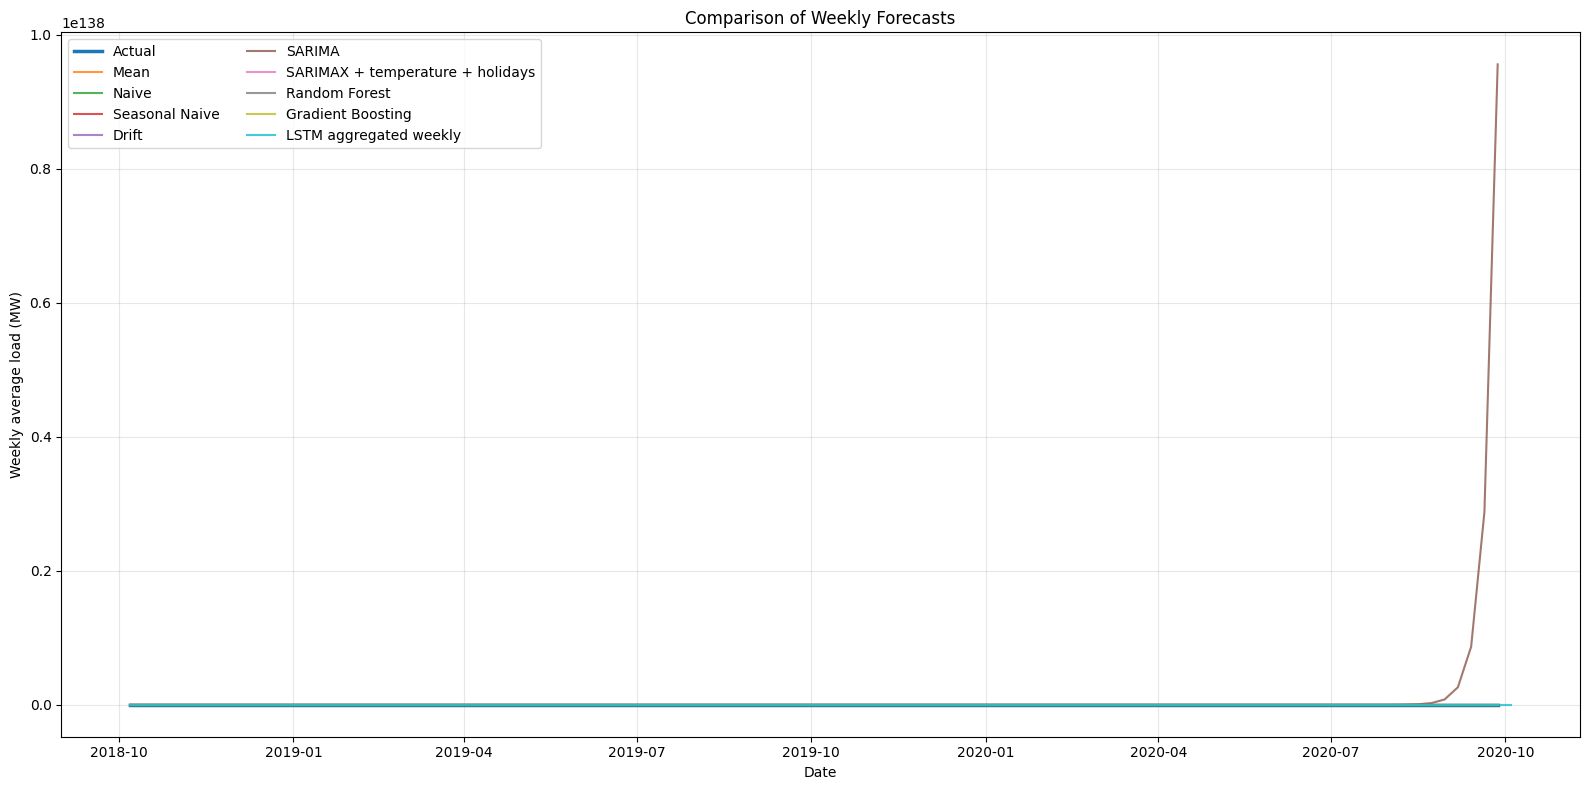

In [ ]:
# 7.6 Combined weekly forecast plot
plt.figure(figsize=(16, 8))

# Select a common weekly actual series.
common_actual = test_weekly.copy()
plt.plot(
    common_actual.index.tz_localize(None),
    common_actual.values,
    label="Actual",
    linewidth=2.5
)

for model_name, forecast in all_forecasts.items():
    forecast_to_plot = forecast.copy()
    forecast_index = pd.DatetimeIndex(forecast_to_plot.index)

    if forecast_index.tz is not None:
        forecast_index = forecast_index.tz_localize(None)

    plt.plot(
        forecast_index,
        forecast_to_plot.values,
        label=model_name,
        alpha=0.8
    )

plt.title("Comparison of Weekly Forecasts")
plt.xlabel("Date")
plt.ylabel("Weekly average load (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Horizon-degradation analysis

,Model,Horizon,Horizon_Weeks,RMSE,MAE,MAPE_percent
10,Seasonal Naive,4 weeks,4,772.87,750.87,1.33
30,Random Forest,4 weeks,4,820.92,639.22,1.13
40,LSTM aggregated weekly,4 weeks,4,"1,214.55","1,196.70",2.13
35,Gradient Boosting,4 weeks,4,"1,219.35",939.58,1.69
5,Naive,4 weeks,4,"1,592.03","1,258.67",2.22
15,Drift,4 weeks,4,"1,592.40","1,258.49",2.22
0,Mean,4 weeks,4,"1,652.91","1,151.83",2.02
25,SARIMAX + temperature + holidays,4 weeks,4,"496,640,059,853,749.38","485,571,230,309,517.50","860,657,339,250.70"
20,SARIMA,4 weeks,4,"33,661,547,460,858,554,113,683,338,470,336,769,...","22,769,407,360,623,307,507,421,757,412,878,438,...","39,416,742,337,445,396,061,732,111,657,833,858,..."
11,Seasonal Naive,13 weeks,13,"1,004.96",881.42,1.53


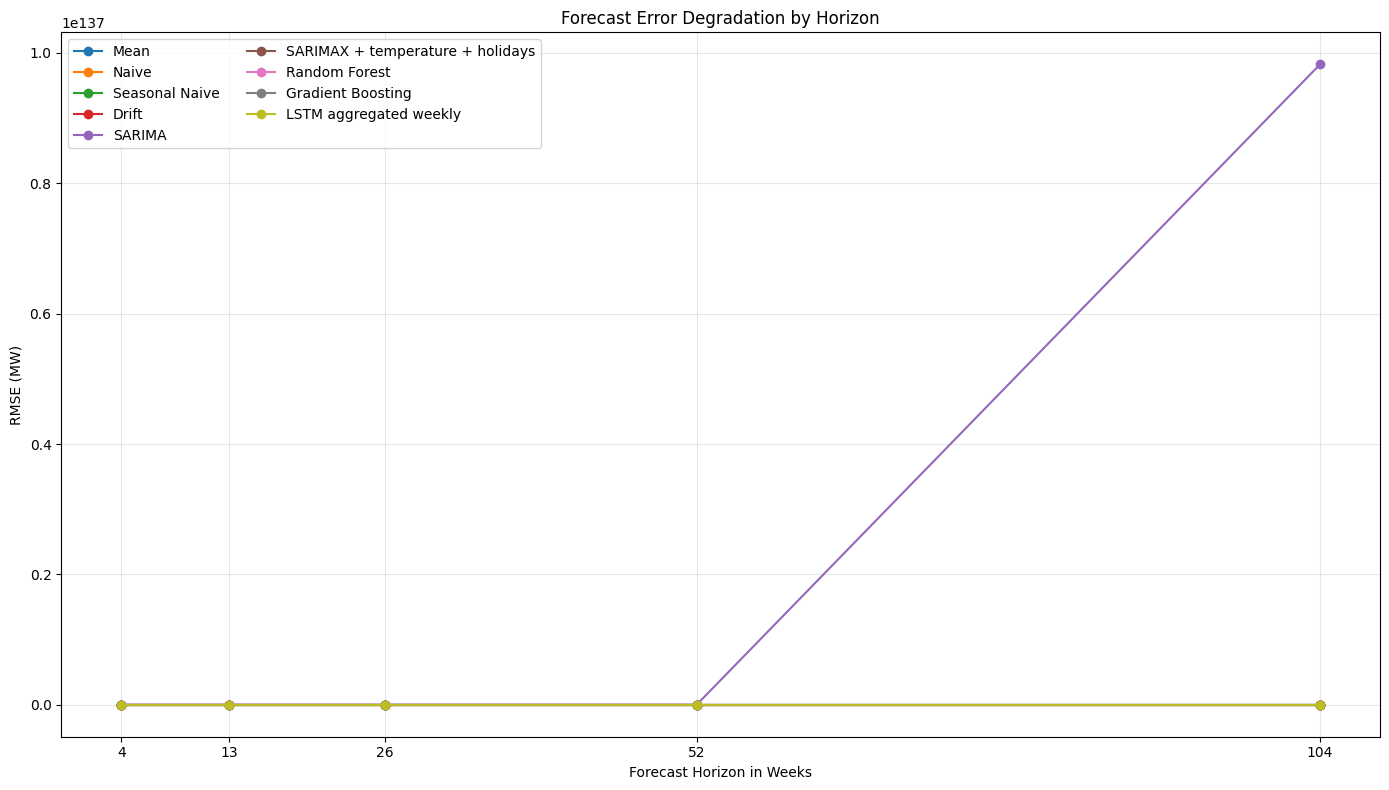

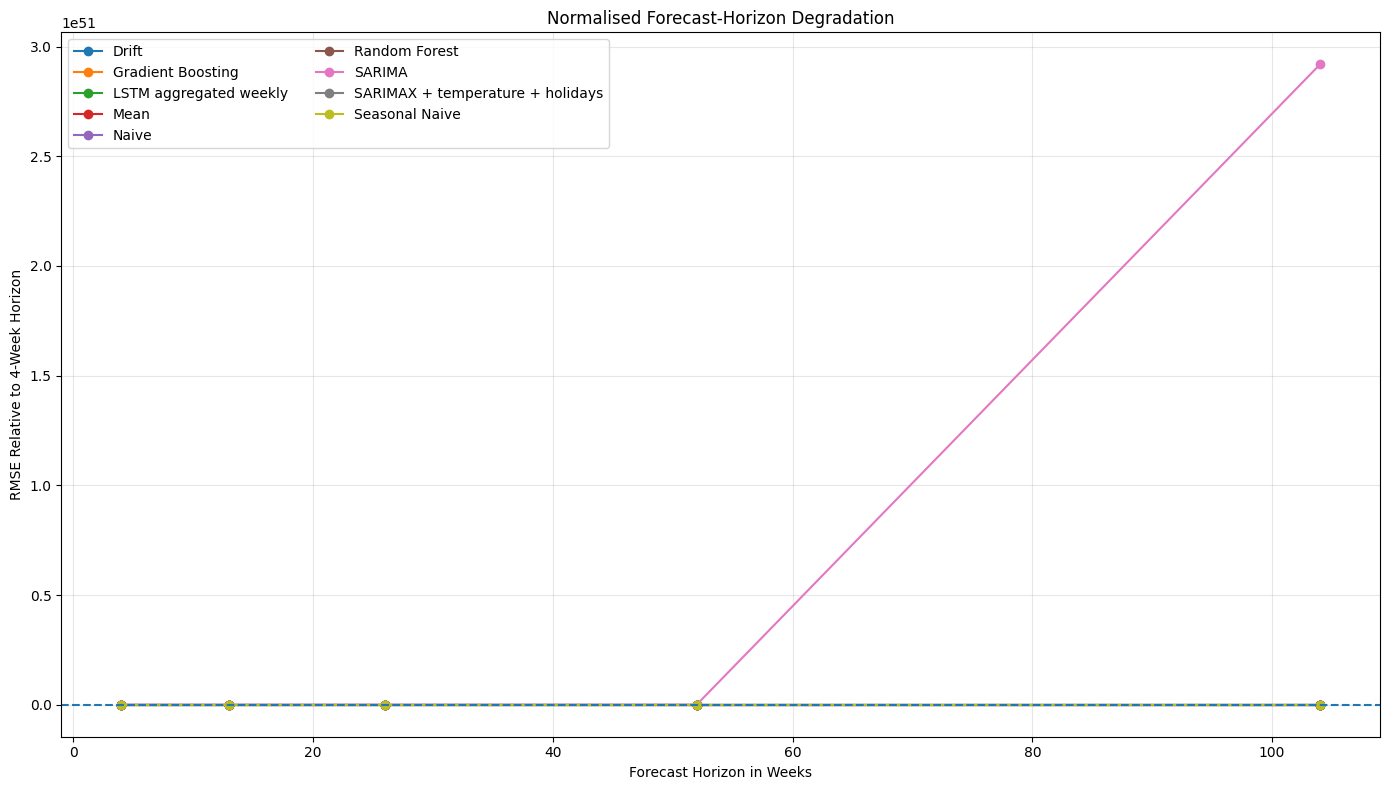

In [ ]:
forecast_horizons = {
    "4 weeks": 4,
    "13 weeks": 13,
    "26 weeks": 26,
    "52 weeks": 52,
    "104 weeks": 104
}


horizon_results = []

for model_name, forecast in clean_forecasts.items():

    common_dates = actual_weekly.index.intersection(
        forecast.index
    )

    actual_common = actual_weekly.loc[
        common_dates
    ]

    forecast_common = forecast.loc[
        common_dates
    ]

    for horizon_name, number_of_weeks in forecast_horizons.items():

        available_weeks = min(
            number_of_weeks,
            len(common_dates)
        )

        if available_weeks < 2:
            continue

        y_true = actual_common.iloc[
            :available_weeks
        ]

        y_pred = forecast_common.iloc[
            :available_weeks
        ]

        horizon_results.append({
            "Model": model_name,
            "Horizon": horizon_name,
            "Horizon_Weeks": number_of_weeks,

            "RMSE": np.sqrt(
                mean_squared_error(
                    y_true,
                    y_pred
                )
            ),

            "MAE": mean_absolute_error(
                y_true,
                y_pred
            ),

            "MAPE_percent": calculate_mape(
                y_true.values,
                y_pred.values
            )
        })


horizon_metrics = pd.DataFrame(
    horizon_results
)

display(
    horizon_metrics.sort_values(
        ["Horizon_Weeks", "RMSE"]
    ).round(3)
)


# RMSE degradation plot
plt.figure(figsize=(14, 8))

for model_name in horizon_metrics["Model"].unique():

    model_data = horizon_metrics[
        horizon_metrics["Model"] == model_name
    ].sort_values("Horizon_Weeks")

    plt.plot(
        model_data["Horizon_Weeks"],
        model_data["RMSE"],
        marker="o",
        label=model_name
    )

plt.title("Forecast Error Degradation by Horizon")
plt.xlabel("Forecast Horizon in Weeks")
plt.ylabel("RMSE (MW)")

plt.xticks(
    sorted(
        horizon_metrics[
            "Horizon_Weeks"
        ].unique()
    )
)

plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Normalised degradation
normalised_metrics = horizon_metrics.sort_values(
    ["Model", "Horizon_Weeks"]
).copy()

normalised_metrics["Initial_RMSE"] = (
    normalised_metrics
    .groupby("Model")["RMSE"]
    .transform("first")
)

normalised_metrics["Normalised_RMSE"] = (
    normalised_metrics["RMSE"] /
    normalised_metrics["Initial_RMSE"]
)


plt.figure(figsize=(14, 8))

for model_name in normalised_metrics["Model"].unique():

    model_data = normalised_metrics[
        normalised_metrics["Model"] == model_name
    ].sort_values("Horizon_Weeks")

    plt.plot(
        model_data["Horizon_Weeks"],
        model_data["Normalised_RMSE"],
        marker="o",
        label=model_name
    )

plt.axhline(
    y=1,
    linestyle="--"
)

plt.title("Normalised Forecast-Horizon Degradation")
plt.xlabel("Forecast Horizon in Weeks")
plt.ylabel("RMSE Relative to 4-Week Horizon")
plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**RANKING CHANGES**

Horizon_Weeks,4,13,26,52,104
Model,,,,,
Drift,6,6,6,5,6
Gradient Boosting,4,2,1,3,3
LSTM aggregated weekly,3,4,2,1,1
Mean,7,7,7,7,5
Naive,5,5,5,6,7
Random Forest,2,3,3,2,2
SARIMA,9,9,9,9,9
SARIMAX + temperature + holidays,8,8,8,8,8
Seasonal Naive,1,1,4,4,4


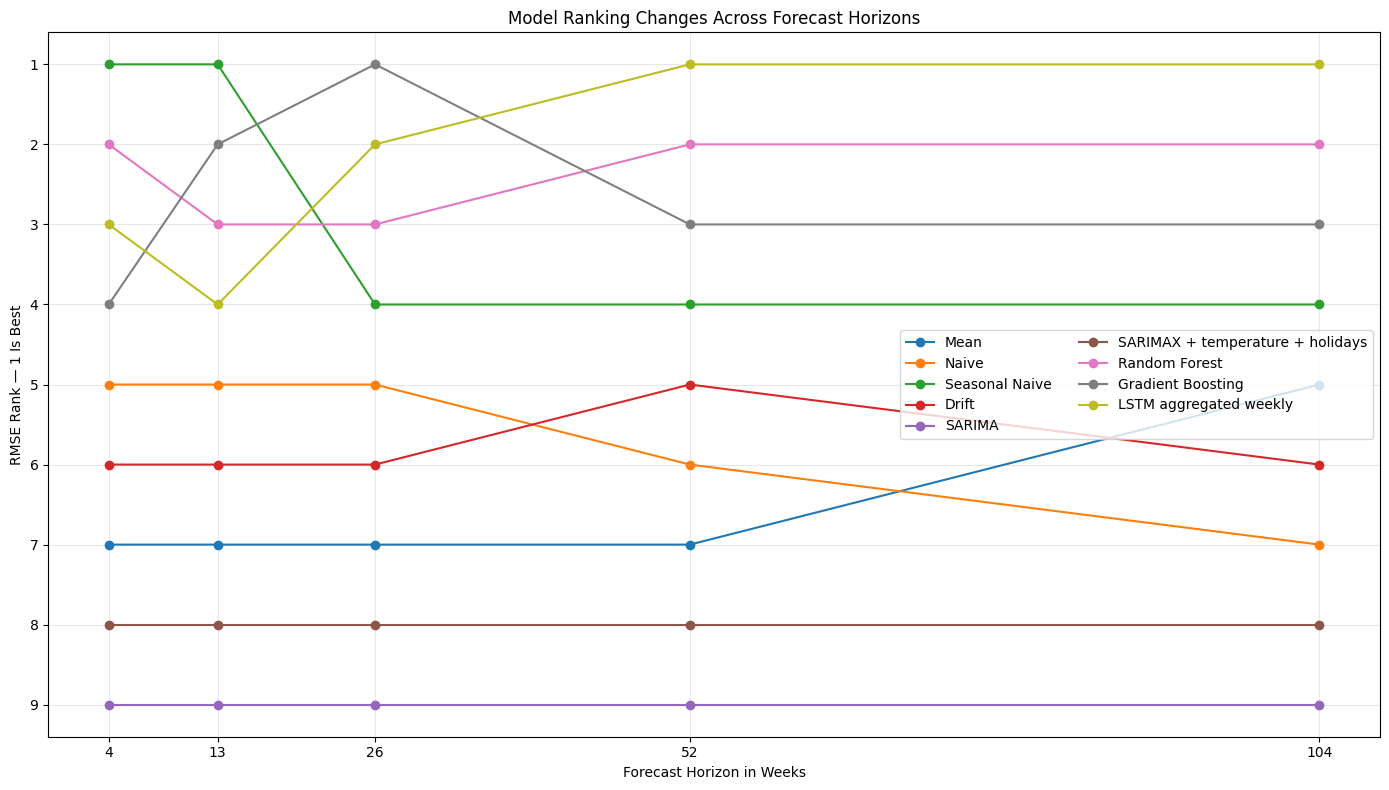

,Model,Short_Horizon_Rank,Long_Horizon_Rank,Rank_Change,Interpretation
8,LSTM aggregated weekly,3,1,-2,Improved at longer horizon
6,Random Forest,2,2,0,No ranking change
7,Gradient Boosting,4,3,-1,Improved at longer horizon
2,Seasonal Naive,1,4,3,Declined at longer horizon
0,Mean,7,5,-2,Improved at longer horizon
3,Drift,6,6,0,No ranking change
1,Naive,5,7,2,Declined at longer horizon
5,SARIMAX + temperature + holidays,8,8,0,No ranking change
4,SARIMA,9,9,0,No ranking change


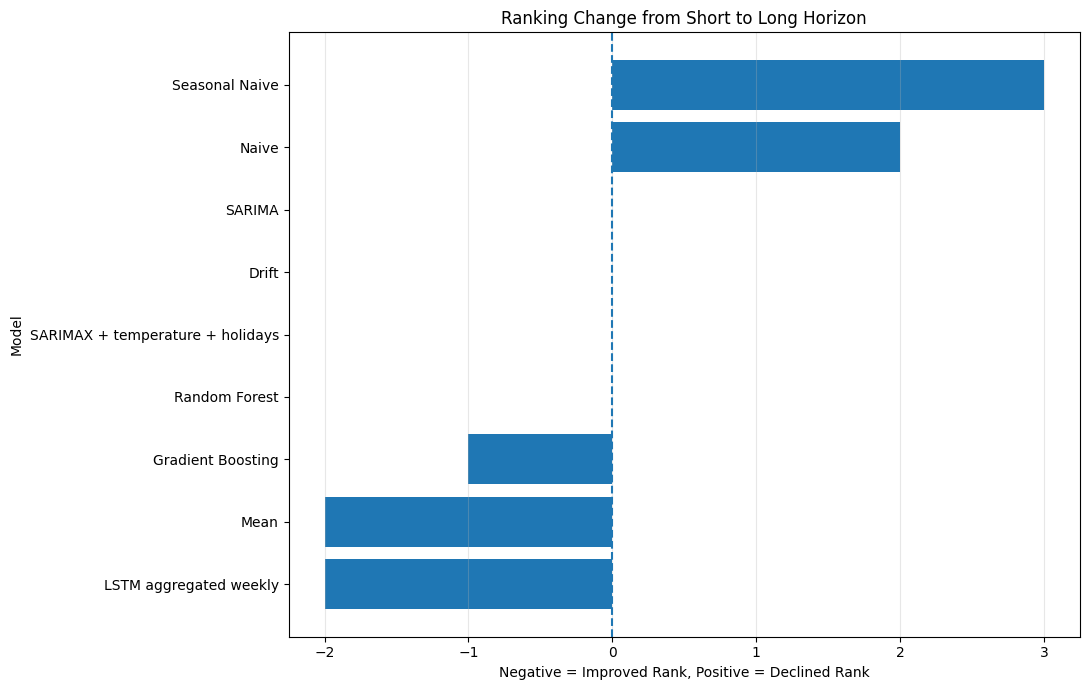

,Horizon,Model,RMSE,RMSE_Rank
0,4 weeks,Seasonal Naive,772.87,1
1,13 weeks,Seasonal Naive,"1,004.96",1
2,26 weeks,Gradient Boosting,"1,209.30",1
3,52 weeks,LSTM aggregated weekly,"1,141.71",1
4,104 weeks,LSTM aggregated weekly,"1,068.95",1


In [ ]:
ranking_table = horizon_metrics.copy()

ranking_table["RMSE_Rank"] = (
    ranking_table
    .groupby("Horizon_Weeks")["RMSE"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)


# Ranking table
ranking_matrix = ranking_table.pivot(
    index="Model",
    columns="Horizon_Weeks",
    values="RMSE_Rank"
)

display(ranking_matrix)


# Ranking-change plot
plt.figure(figsize=(14, 8))

for model_name in ranking_table["Model"].unique():

    model_rank = ranking_table[
        ranking_table["Model"] == model_name
    ].sort_values("Horizon_Weeks")

    plt.plot(
        model_rank["Horizon_Weeks"],
        model_rank["RMSE_Rank"],
        marker="o",
        label=model_name
    )

plt.title("Model Ranking Changes Across Forecast Horizons")
plt.xlabel("Forecast Horizon in Weeks")
plt.ylabel("RMSE Rank — 1 Is Best")

plt.xticks(
    sorted(
        ranking_table[
            "Horizon_Weeks"
        ].unique()
    )
)

plt.yticks(
    range(
        1,
        ranking_table["RMSE_Rank"].max() + 1
    )
)

plt.gca().invert_yaxis()

plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Compare shortest and longest horizon rankings
shortest_horizon = ranking_table[
    "Horizon_Weeks"
].min()

longest_horizon = ranking_table[
    "Horizon_Weeks"
].max()


short_ranks = ranking_table[
    ranking_table["Horizon_Weeks"] ==
    shortest_horizon
][["Model", "RMSE_Rank"]].rename(
    columns={
        "RMSE_Rank": "Short_Horizon_Rank"
    }
)


long_ranks = ranking_table[
    ranking_table["Horizon_Weeks"] ==
    longest_horizon
][["Model", "RMSE_Rank"]].rename(
    columns={
        "RMSE_Rank": "Long_Horizon_Rank"
    }
)


ranking_changes = short_ranks.merge(
    long_ranks,
    on="Model"
)

ranking_changes["Rank_Change"] = (
    ranking_changes["Long_Horizon_Rank"] -
    ranking_changes["Short_Horizon_Rank"]
)

ranking_changes["Interpretation"] = np.select(
    [
        ranking_changes["Rank_Change"] < 0,
        ranking_changes["Rank_Change"] > 0
    ],
    [
        "Improved at longer horizon",
        "Declined at longer horizon"
    ],
    default="No ranking change"
)

ranking_changes = ranking_changes.sort_values(
    "Long_Horizon_Rank"
)

display(ranking_changes)


# Rank-change visualisation
plt.figure(figsize=(11, 7))

ranking_plot = ranking_changes.sort_values(
    "Rank_Change"
)

plt.barh(
    ranking_plot["Model"],
    ranking_plot["Rank_Change"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Ranking Change from Short to Long Horizon")
plt.xlabel(
    "Negative = Improved Rank, Positive = Declined Rank"
)
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


# Best model at each horizon
best_model_each_horizon = (
    ranking_table
    .sort_values(
        ["Horizon_Weeks", "RMSE_Rank"]
    )
    .groupby(
        "Horizon_Weeks",
        as_index=False
    )
    .first()
)

display(
    best_model_each_horizon[
        [
            "Horizon",
            "Model",
            "RMSE",
            "RMSE_Rank"
        ]
    ].round(3)
)